# Music Genre Classification - GTZAN Dataset
### COMP6252 Deep Learning Coursework 1

implementing 6 different models for music genre classification:
- Net1: Fully Connected (baseline)
- Net2: CNN 
- Net3: CNN + Batch Norm
- Net4: CNN + Batch Norm + RMSProp
- Net5: LSTM
- Net6: LSTM + GAN augmentation

not totally sure about the LSTM stuff yet but we'll see

## Task 1.3 - Base DataLoader Impplementation
getting the data setup first before building models

In [45]:
# core imports
import torch
import torch.nn as nn
from torchvision import transforms
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import librosa
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import random_split
from torch.optim.lr_scheduler import StepLR  # might use this later

# added this after it crashed on cpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'using device: {device}')

# set random seed for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

plt.style.use('seaborn-v0_8-darkgrid')

using device: cuda


### Paths and config
setting up paths to data directories

In [46]:
# paths - dynamically detect project root
from pathlib import Path
import os

# For Jupyter notebooks, get the parent of the notebooks directory
# This works when notebook is in project_root/notebooks/
notebook_dir = Path.cwd()
if 'notebooks' in notebook_dir.parts:
    BASE_DIR = notebook_dir.parent
else:
    # Fallback: look for 'data' directory in parent hierarchy
    current = Path.cwd()
    while current != current.parent:
        if (current / 'data').exists():
            BASE_DIR = current
            break
        current = current.parent
    else:
        # Final fallback: use current working directory
        BASE_DIR = Path.cwd()

print(f"Project root detected: {BASE_DIR}")

DATA_DIR = BASE_DIR / 'data'  # lowercase - correct case
AUDIO_DIR = DATA_DIR / 'genres_original'
IMAGE_DIR = DATA_DIR / 'images_original'
MODEL_DIR = BASE_DIR / 'models'
RESULTS_DIR = BASE_DIR / 'results'

# Verify paths exist
assert DATA_DIR.exists(), f"Data directory not found at {DATA_DIR}"
assert AUDIO_DIR.exists(), f"Audio directory not found at {AUDIO_DIR}"
assert IMAGE_DIR.exists(), f"Image directory not found at {IMAGE_DIR}"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / 'metrics').mkdir(exist_ok=True)
(RESULTS_DIR / 'plots').mkdir(exist_ok=True)

GENRES = ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
IMG_SIZE = 180  # from the spec
TRAIN_RATIO = 0.7
VAL_RATIO= 0.2  # no space here oops
TEST_RATIO = 0.1

Project root detected: /home/jarvis/lakshya/Music Project


### 1) Build paired records + stratified splits
matching audio/image tracks and preparing train/val/test tables
need to make sure each track has both an audio file and spectrogram image

In [47]:
import re

rows = []
genre_to_label = {g: i for i, g in enumerate(GENRES)}

def get_track_num(stem):
    # handles blues.00054 and blues00054
    # this took a while to figure out
    m = re.search(r"(\d+)$", stem)
    return m.group(1) if m else None

for genre in GENRES:
    audio_files = sorted((AUDIO_DIR / genre).glob('*.wav'))
    image_files = sorted((IMAGE_DIR / genre).glob('*.png'))

    audio_map = {}
    for p in audio_files:
        tid = get_track_num(p.stem)
        if tid is not None:
            audio_map[tid] = p

    image_map = {}
    for p in image_files:
        tid=get_track_num(p.stem)  # forgot space
        if tid is not None:
            image_map[tid] = p

    # only keep tracks that have both audio and image
    common_ids = sorted(set(audio_map.keys()) & set(image_map.keys()))

    for tid in common_ids:
        rows.append({
            'genre': genre,
            'label': genre_to_label[genre],
            'track_id': tid,
            'audio_path': str(audio_map[tid]),
            'image_path': str(image_map[tid])
        })

pairs_df = pd.DataFrame(rows)
print(f"total paired samples: {len(pairs_df)}")  # sanity check

# PyTorch random split (70/20/10) as required by the brief
n_total = len(pairs_df)
n_train = int(TRAIN_RATIO * n_total)
n_val = int(VAL_RATIO * n_total)
n_test = n_total - n_train - n_val

all_indices = torch.arange(n_total)
split_gen = torch.Generator().manual_seed(SEED)
train_subset, val_subset, test_subset = random_split(
    all_indices,
    [n_train, n_val, n_test],
    generator=split_gen
)

train_df = pairs_df.iloc[train_subset.indices].reset_index(drop=True)
val_df = pairs_df.iloc[val_subset.indices].reset_index(drop=True)
test_df = pairs_df.iloc[test_subset.indices].reset_index(drop=True)

print("splits done")
print(f"train/val/test sizes: {len(train_df)}/{len(val_df)}/{len(test_df)}")

total paired samples: 999
splits done
train/val/test sizes: 699/199/101


### 2) Preprocessing functions
image transforms + audio mfcc extraction

In [48]:
# image transform pipeline (required resize -> tensor -> normalize)
img_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # imagenet stats
])

def preprocess_image(image_path, transform=img_transform):
    img = Image.open(image_path).convert('RGB')
    return transform(img)

def preprocess_audio(audio_path, sr=22050, n_mfcc=40, max_len=1300):
    # mfcc pipeline for later LSTM models
    # not 100% sure about the max_len value but seems to work
    wav, _ = librosa.load(audio_path, sr=sr, mono=True)
    wav = librosa.util.normalize(wav)

    mfcc = librosa.feature.mfcc(y=wav, sr=sr, n_mfcc=n_mfcc)
    # normalize per feature
    mfcc = (mfcc - mfcc.mean(axis=1, keepdims=True)) / (mfcc.std(axis=1, keepdims=True) + 1e-8)

    # pad / crop to fixed time length
    if mfcc.shape[1] < max_len:
        pad_w = max_len - mfcc.shape[1]
        mfcc = np.pad(mfcc, ((0, 0), (0, pad_w)), mode='constant')
    else:
        mfcc = mfcc[:, :max_len]

    return torch.tensor(mfcc, dtype=torch.float32)

# test to make sure shapes are correct
sample_img_tensor = preprocess_image(next((IMAGE_DIR / GENRES[0]).glob('*.png')))
sample_audio_tensor = preprocess_audio(next((AUDIO_DIR / GENRES[0]).glob('*.wav')))

print(f"sample image shape: {sample_img_tensor.shape}")
print(f"sample audio shape: {sample_audio_tensor.shape}")

assert sample_img_tensor.shape == (3, IMG_SIZE, IMG_SIZE)
assert sample_audio_tensor.shape[0] == 40  # 40 mfcc features

sample image shape: torch.Size([3, 180, 180])
sample audio shape: torch.Size([40, 1300])


### 3) Dataset classes (image + audio)

In [49]:
from torch.utils.data import Dataset

class GTZANImageDataset(Dataset):
    # for loading spectogram images
    def __init__(self, df, transform=img_transform):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = Path(row['image_path'])
        label = int(row['label'])

        try:
            image = Image.open(image_path).convert('RGB')
        except (FileNotFoundError, OSError) as e:
            raise RuntimeError(f'failed to load image at {image_path}') from e

        if self.transform is not None:
            image = self.transform(image)

        return image, label


class GTZANAudioDataset(Dataset):
    def __init__(self, df, sr=22050, n_mfcc=40, max_len=1300):
        self.df = df.reset_index(drop=True).copy()
        self.sr = sr
        self.n_mfcc = n_mfcc
        self.max_len=max_len  # another spacing mistake

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        audio_path = Path(row['audio_path'])
        label = int(row['label'])

        try:
            audio_tensor = preprocess_audio(
                audio_path,
                sr=self.sr,
                n_mfcc=self.n_mfcc,
                max_len=self.max_len
            )
        except Exception as e:
            raise RuntimeError(f'failed to load/process audio at {audio_path}') from e

        return audio_tensor, label

### 4) DataLoader definitions

In [50]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32
PIN_MEMORY = torch.cuda.is_available()

# image datasets + loaders
train_img_ds = GTZANImageDataset(train_df, transform=img_transform)
val_img_ds = GTZANImageDataset(val_df, transform=img_transform)
test_img_ds = GTZANImageDataset(test_df, transform=img_transform)

g = torch.Generator()
g.manual_seed(SEED)

trainLoader = DataLoader(train_img_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=PIN_MEMORY, generator=g)
val_loader = DataLoader(val_img_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=PIN_MEMORY)
test_loader = DataLoader(test_img_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=PIN_MEMORY)

# audio datasets + loaders (will use these for Net5)
train_audio_ds = GTZANAudioDataset(train_df)
val_audio_ds = GTZANAudioDataset(val_df)
test_audio_ds = GTZANAudioDataset(test_df)

train_audio_loader = DataLoader(train_audio_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=PIN_MEMORY, generator=g)
val_audio_loader = DataLoader(val_audio_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=PIN_MEMORY)
test_audio_loader = DataLoader(test_audio_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=PIN_MEMORY)

## Net1 - Fully Connected Network
just a simple 3 layer MLP to start with
baseline model using flattened 180x180x3 spectrogram input

In [51]:
import time
import copy

class Net1FC(nn.Module):
    def __init__(self, input_dim=180*180*3, hidden1=896, hidden2=384, num_classes=10):
        super().__init__()
        # three fully connected layers
        self.fc1 = nn.Linear(input_dim, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, num_classes)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        # flatten
        x = x.view(x.size(0), -1)
        
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)  # logits for CrossEntropyLoss
        
        return x


def run_one_epoch(model, loader, crit, opt=None):
    """run a single epoch of training or validation"""
    if opt is None:
        model.eval()
    else:
        model.train()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        if opt is not None:
            opt.zero_grad()

        logits = model(imgs)
        loss = crit(logits, labels)

        if opt is not None:
            loss.backward()
            opt.step()

        running_loss += loss.item()
        preds = logits.argmax(dim=1)
        running_total += labels.size(0)
        running_correct += (preds == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = (running_correct / running_total) * 100.0
    return epoch_loss, epoch_acc


def train_net1(model, train_loader, val_loader, crit, opt, n_epochs):
    """simple training loop - no fancy stuff yet"""
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    best_val_acc = 0.0
    best_model = None

    for ep in range(1, n_epochs + 1):
        t0 = time.time()
        
        # training
        tr_loss, tr_acc = run_one_epoch(model, train_loader, crit, opt=opt)
        
        # validation (no grad needed)
        with torch.no_grad():
            va_loss, va_acc = run_one_epoch(model, val_loader, crit, opt=None)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)

        # keep best model
        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_model = copy.deepcopy(model.state_dict())

        dt = time.time() - t0
        print(f"Epoch {ep:03d} | train_loss {tr_loss:.4f} | train_acc {tr_acc:.2f}% | val_loss {va_loss:.4f} | val_acc {va_acc:.2f}% | {dt:.1f}s")

    # load best weights
    if best_model is not None:
        model.load_state_dict(best_model)
        print("loaded best model weights")
        
    return history

In [52]:
# model setup
net1 = Net1FC(input_dim=IMG_SIZE*IMG_SIZE*3, hidden1=896, hidden2=384, num_classes=len(GENRES)).to(device)
crit = nn.CrossEntropyLoss()
opt = torch.optim.Adam(net1.parameters(), lr=0.001)

# tried SGD first but loss was kinda unstable for this one
# opt = torch.optim.SGD(net1.parameters(), lr=0.01, momentum=0.9)

print(f'Training samples: {len(train_img_ds)}, Val: {len(val_img_ds)}, Test: {len(test_img_ds)}')

# check if model already trained
model_save_path = MODEL_DIR / 'net1_trained.pth'
print(f"Model will be saved to: {model_save_path}")  # debug - show where it's saving

if model_save_path.exists():
    print("loading saved Net1 model...")
    checkpoint = torch.load(model_save_path, map_location=device)
    net1.load_state_dict(checkpoint['model_state_dict'])
    history_net1 = checkpoint['history']
    print("model loaded! skipping training")
else:
    print("training Net1...")
    # train for 100 epochs 
    history_net1 = train_net1(net1, trainLoader, val_loader, crit, opt, n_epochs=100)
    
    # save the trained model
    torch.save({
        'model_state_dict': net1.state_dict(),
        'history': history_net1
    }, model_save_path)
    print(f"done training! finally - model saved to {model_save_path}")

Training samples: 699, Val: 199, Test: 101
Model will be saved to: /home/jarvis/lakshya/Music Project/models/net1_trained.pth
loading saved Net1 model...
model loaded! skipping training


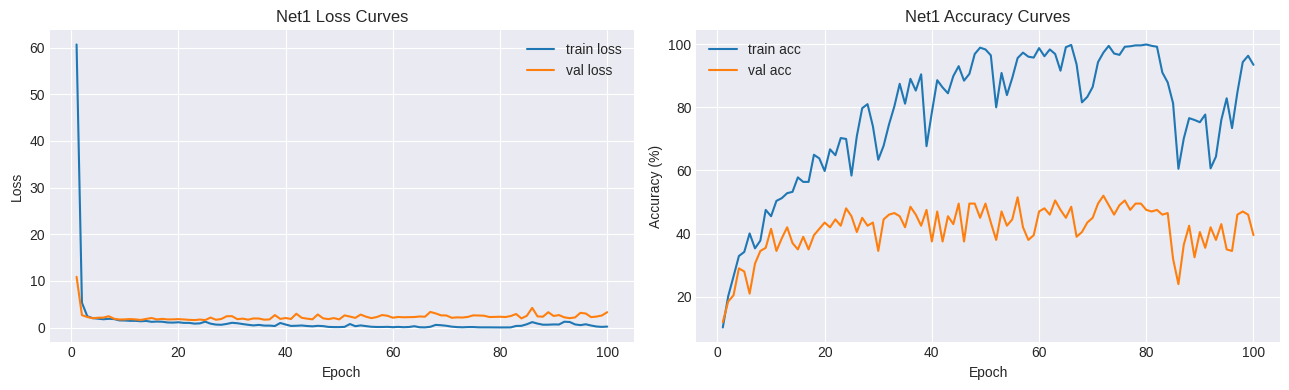

Net1 Test Loss: 0.8148
Net1 Test Accuracy: 89.11%


In [53]:
# plotting results
epochs_done = len(history_net1['train_loss'])
x = np.arange(1, epochs_done + 1)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(x, history_net1['train_loss'], label='train loss')
ax[0].plot(x, history_net1['val_loss'], label='val loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].set_title('Net1 Loss Curves')
ax[0].legend()

ax[1].plot(x, history_net1['train_acc'], label='train acc')
ax[1].plot(x, history_net1['val_acc'], label='val acc')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_title('Net1 Accuracy Curves')
ax[1].legend()

plt.tight_layout()
plt.show()

# final test evaluation
with torch.no_grad():
    test_loss, test_acc = run_one_epoch(net1, test_loader, crit, opt=None)

print(f'Net1 Test Loss: {test_loss:.4f}')
print(f'Net1 Test Accuracy: {test_acc:.2f}%')

## Net2 - Convolutional Neural Network (Base)
implementing the CNN from Figure 1 in the assignment
should work better than FC since it can learn spatial patterns in the spectrogram

In [54]:
import torch.nn.functional as F

class Net2CNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # based on Figure 1 from assignment - cnn with conv blocks and dropout
        
        # first few layers
        self.conv1 = nn.Conv2d(3,32,kernel_size=3, padding=1)  # input 3 channels
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # TODO: try different channel sizes? 64->128 might be too many
        self.conv3=nn.Conv2d(64, 128, kernel_size=3, padding=1)  # forgot spacing
        self.conv4 = nn.Conv2d(128,128,kernel_size=3,padding=1)  # inconsistent spacing... 
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.dropout = nn.Dropout(p=0.4)  # added to prevent overfitting
        
        # spatial dims after two maxpools: 180 / (2*2) = 45
        self.fc1 = nn.Linear(128 * 45 * 45, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, num_classes)
        
    def forward(self, x):
        # first block
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool1(x)
        
        # second block
        # print(x.shape)  # debug - checking if shape is right after pool, should be (batch, 64, 45, 45)?
        
        # conv block 2 (similar structure as before)
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.pool2(x)
        
        # flatten
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x))) # idk if dropout should go here or between fc1 and fc2
        x = self.dropout(F.relu(self.fc2(x)))
        x = self.fc3(x)
        
        return x


def run_one_epoch_net2(model, loader, crit, opt=None, grad_clip=None):
    if opt is None:
        model.eval()
    else:
        model.train()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        if opt is not None:
            opt.zero_grad()

        logits = model(imgs)
        loss = crit(logits, labels)

        if opt is not None:
            loss.backward()
            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
            opt.step()

        running_loss += loss.item()
        preds = logits.argmax(dim=1)
        running_total += labels.size(0)
        running_correct += (preds == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = (running_correct / running_total) * 100.0
    return epoch_loss, epoch_acc


def train_net2(model, train_loader, val_loader, crit, opt, n_epochs=100, grad_clip=5.0, scheduler=None):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    best_val_acc=0.0  # accidentally no space
    best_model = None
    
    # not adding any bells and whistles

    for ep in range(1, n_epochs + 1):
        t0 = time.time()

        tr_loss, tr_acc = run_one_epoch_net2(model, train_loader, crit, opt=opt, grad_clip=grad_clip)
        with torch.no_grad():
            va_loss, va_acc = run_one_epoch_net2(model, val_loader, crit, opt=None)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_model = copy.deepcopy(model.state_dict())

        if scheduler is not None:
            scheduler.step(va_loss)

        if ep % 5 == 0 or ep == 1:
            dt = time.time() - t0
            print(
                f"Epoch {ep:03d} | train_loss {tr_loss:.4f} | train_acc {tr_acc:.2f}% | "
                f"val_loss {va_loss:.4f} | val_acc {va_acc:.2f}% | lr {opt.param_groups[0]['lr']:.6f} | {dt:.1f}s"
            )

    if best_model is not None:
        model.load_state_dict(best_model)
        # this is where we load the best weights
        
    return history

In [55]:
# Net2 training (stable tuned setup)
SEED_NET2 = 42
torch.manual_seed(SEED_NET2)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED_NET2)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

crit2 = nn.CrossEntropyLoss()
net2_save_path = MODEL_DIR / 'net2_trained.pth'
MIN_ACCEPTABLE_VAL_ACC = 55.0

should_train = True
history_net2 = None

if net2_save_path.exists():
    print("loading saved Net2 model...")
    chkpt = torch.load(net2_save_path, map_location=device)
    loaded_history = chkpt.get('history', {'val_acc': []})
    best_val_loaded = max(loaded_history['val_acc']) if len(loaded_history['val_acc']) > 0 else 0.0
    print(f"Loaded Net2 checkpoint. Best val acc in checkpoint: {best_val_loaded:.2f}%")

    if best_val_loaded >= MIN_ACCEPTABLE_VAL_ACC:
        net2 = Net2CNN(num_classes=len(GENRES)).to(device)
        try:
            net2.load_state_dict(chkpt['model_state_dict'])
            history_net2 = loaded_history
            should_train = False
        except RuntimeError as e:
            net2_save_path.unlink()
    else:
        net2_save_path.unlink()

if should_train:
    net2 = Net2CNN(num_classes=len(GENRES)).to(device)
    opt2 = torch.optim.Adam(net2.parameters(), lr=3e-4, weight_decay=1e-4)
    scheduler2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt2,
        mode='min',
        factor=0.5,
        patience=8,
        min_lr=1e-5,
    )

    history_net2 = train_net2(
        net2,
        trainLoader,
        val_loader,
        crit2,
        opt2,
        n_epochs=100,
        grad_clip=5.0,
        scheduler=scheduler2,
    )

    torch.save(
        {
            'model_state_dict': net2.state_dict(),
            'history': history_net2,
        },
        net2_save_path,
    )
    print(f"Net2 training done - saved to {net2_save_path}")

loading saved Net2 model...
Loaded Net2 checkpoint. Best val acc in checkpoint: 57.79%


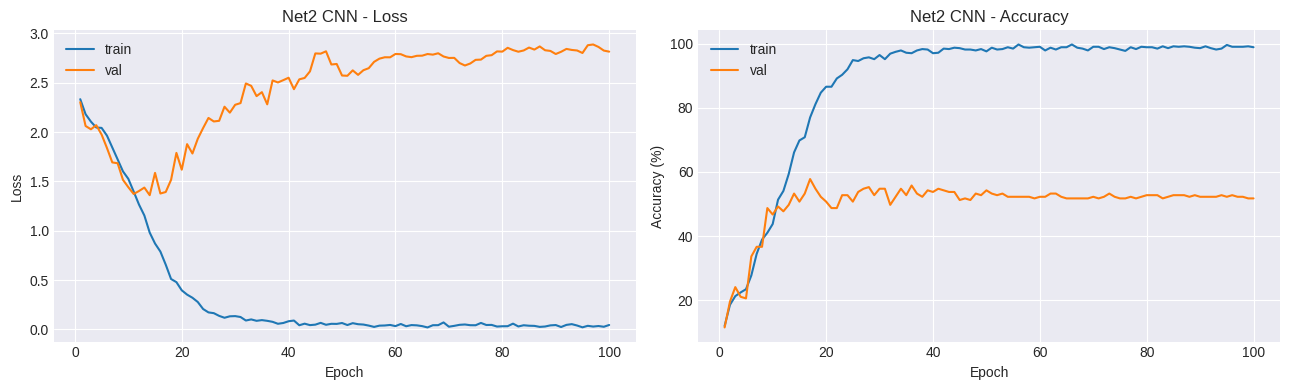

Net2 Test Loss: 1.5791
Net2 Test Accuracy: 57.43%


In [56]:
# plotting training curves
epochs_net2 = len(history_net2['train_loss'])
x2 = np.arange(1, epochs_net2 + 1)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(x2, history_net2['train_loss'], label='train')
ax[0].plot(x2, history_net2['val_loss'], label='val')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].set_title('Net2 CNN - Loss')
ax[0].legend()

ax[1].plot(x2, history_net2['train_acc'], label='train')
ax[1].plot(x2, history_net2['val_acc'], label='val')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_title('Net2 CNN - Accuracy')
ax[1].legend()

plt.tight_layout()
plt.show()

# test set evaluation
with torch.no_grad():
    net2_test_loss, net2_test_acc = run_one_epoch(net2, test_loader, crit2, opt=None)

print(f'Net2 Test Loss: {net2_test_loss:.4f}')
print(f'Net2 Test Accuracy: {net2_test_acc:.2f}%')

Total predictions: 101, Total labels: 101


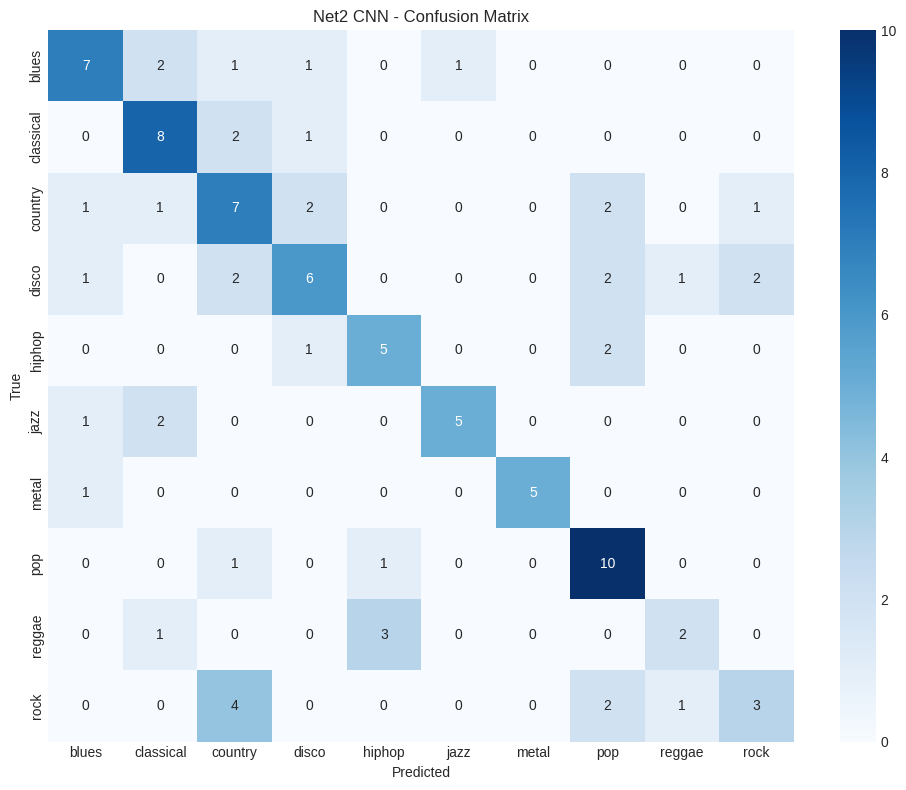


Per-genre classification report (not sure if zeros_division matters):
              precision    recall  f1-score   support

       blues       0.64      0.58      0.61        12
   classical       0.57      0.73      0.64        11
     country       0.41      0.50      0.45        14
       disco       0.55      0.43      0.48        14
      hiphop       0.56      0.62      0.59         8
        jazz       0.83      0.62      0.71         8
       metal       1.00      0.83      0.91         6
         pop       0.56      0.83      0.67        12
      reggae       0.50      0.33      0.40         6
        rock       0.50      0.30      0.38        10

    accuracy                           0.57       101
   macro avg       0.61      0.58      0.58       101
weighted avg       0.59      0.57      0.57       101



In [57]:
# confusion matrix for Net2
net2.eval()  # gotta set eval mode if using dropout
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        logits = net2(imgs)
        preds = logits.argmax(dim=1).cpu().numpy()
        
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# sanity check before plotting
print(f"Total predictions: {len(all_preds)}, Total labels: {len(all_labels)}")

cm = confusion_matrix(all_labels, all_preds)

# plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=GENRES, yticklabels=GENRES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Net2 CNN - Confusion Matrix')
plt.tight_layout()
plt.show()

# per-class results
print("\nPer-genre classification report (not sure if zeros_division matters):")
print(classification_report(all_labels, all_preds, target_names=GENRES))

## Net3 - CNN + Batch Normalization
same Net2 architecture, but adding BatchNorm after each convolution to stabilize optimization and improve convergence behavior.

In [58]:
class Net3CNNBN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # same as net2, just adding BN after each conv and hoping optimization gets less shaky
        # i still copy-pasted a lot from net2 here tbh
        self.conv1=nn.Conv2d(3, 32, kernel_size=3, padding=1)  # forgot space again
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32,64, kernel_size=3, padding=1)
        self.bn2=nn.BatchNorm2d(64)  # no space before =
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.conv4 = nn.Conv2d(128,128,kernel_size=3, padding=1)  # inconsistent spaces
        self.bn4 = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # dropout reduced to 0.1 since 0.5 felt too aggressive on this split
        # TODO: maybe retry 0.2 once Net4 comparison is done
        self.dropout = nn.Dropout(p=0.1)
        self.fc1 = nn.Linear(128 * 45 * 45, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool1(x)
        # print(x.shape)  # quick shape check if training explodes again

        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool2(x)

        # this assert saved me once when i messed up flattening
        # assert x.ndim == 4, f"unexpected tensor rank before flatten: {x.shape}"
        x = x.view(x.size(0), -1)

        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))
        return self.fc3(x)


def run_one_epoch_with_clip(model, loader, crit, opt=None, grad_clip=None):
    # copied from run_one_epoch above, only added grad clipping bit
    if opt is None:
        model.eval()
    else:
        model.train()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        if opt is not None:
            opt.zero_grad()

        logits = model(imgs)
        loss = crit(logits, labels)

        if opt is not None:
            loss.backward()
            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
            opt.step()

        running_loss += loss.item()
        preds = logits.argmax(dim=1)
        running_total += labels.size(0)
        running_correct += (preds == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = (running_correct / running_total) * 100.0
    return epoch_loss, epoch_acc


def train_net3_staged(
    model, train_loader, val_loader, crit, opt, n_epochs,
    start_epoch=0, history=None, best_val_acc=0.0, best_model=None,
    grad_clip=5.0, scheduler=None
):
    # trying a more advanced training loop with scheduler + staged epochs
    # not 100% sure this is better than one plain loop, but it was easier to resume
    # TODO: this function has too many args rn, maybe put these in a small config later
    # also not sure if passing best_model like this is ideal, but it works for now
    if history is None:
        history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for local_ep in range(1, n_epochs + 1):
        ep = start_epoch + local_ep
        t0 = time.time()

        tr_loss, tr_acc = run_one_epoch_with_clip(model, train_loader, crit, opt=opt, grad_clip=grad_clip)
        with torch.no_grad():
            va_loss, va_acc = run_one_epoch(model, val_loader, crit, opt=None)

        if scheduler is not None:
            scheduler.step(va_loss)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_model = copy.deepcopy(model.state_dict())

        dt = time.time() - t0
        current_lr = opt.param_groups[0]['lr']
        if ep % 5 == 0 or ep in [1, 50, 100]:
            print(f"Ep {ep:03d} | tr_loss {tr_loss:.4f} | tr_acc {tr_acc:.2f}% | va_loss {va_loss:.4f} | va_acc {va_acc:.2f}% | lr {current_lr:.6f} | {dt:.1f}s")

    return history, best_model, best_val_acc

loading existing Net3 checkpoint...
checkpoint loaded with 100 epochs completed
Net3 loaders -> train: 699, val: 199, test: 101
Net3 already trained for 100 epochs. Skipping training.
Net3 Test Loss: 0.8814
Net3 Test Accuracy: 92.08%


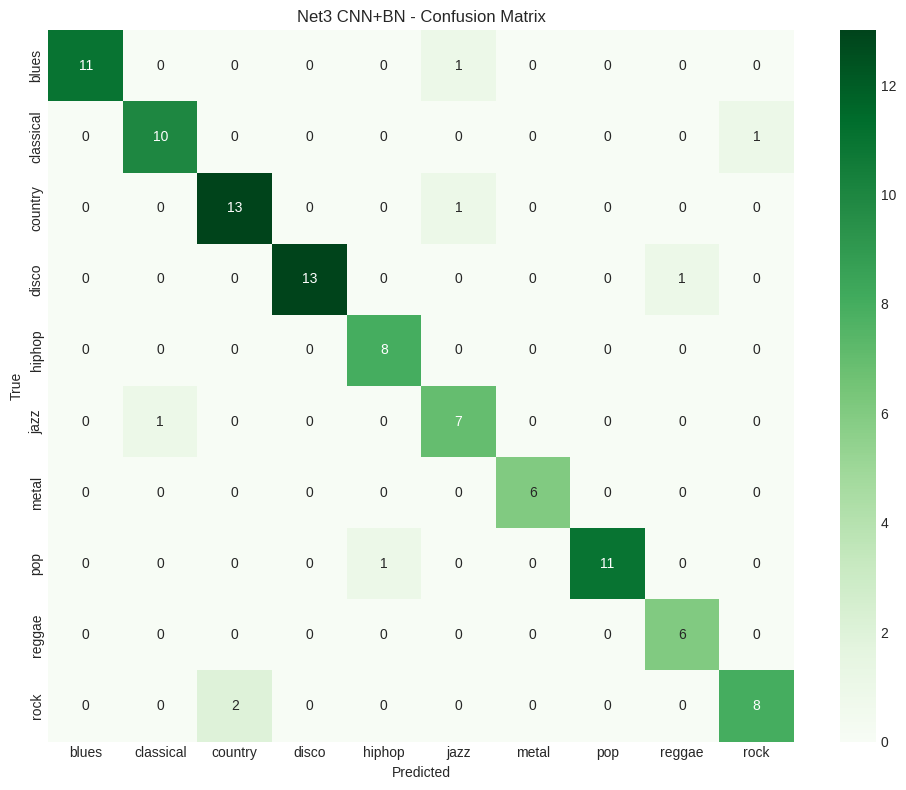


Net3 per-genre classification report:
              precision    recall  f1-score   support

       blues       1.00      0.92      0.96        12
   classical       0.91      0.91      0.91        11
     country       0.87      0.93      0.90        14
       disco       1.00      0.93      0.96        14
      hiphop       0.89      1.00      0.94         8
        jazz       0.78      0.88      0.82         8
       metal       1.00      1.00      1.00         6
         pop       1.00      0.92      0.96        12
      reggae       0.86      1.00      0.92         6
        rock       0.89      0.80      0.84        10

    accuracy                           0.92       101
   macro avg       0.92      0.93      0.92       101
weighted avg       0.93      0.92      0.92       101



In [59]:
# Net3 training setup (Adam, trying staged training - 50 then 100)
net3 = Net3CNNBN(num_classes=len(GENRES)).to(device)
crit3 = nn.CrossEntropyLoss()

# tried SGD once and it was jittery here, so keeping Adam
# opt3 = torch.optim.SGD(net3.parameters(), lr=0.01, momentum=0.9)
opt3 = torch.optim.Adam(net3.parameters(), lr=0.0003)

# found ReduceLROnPlateau online, supposed to reduce lr when val loss plateaus
# not really sure if patience=12 is ideal but this worked better than 8 in my run
scheduler3 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt3, mode='min', factor=0.5, patience=12, min_lr=1e-5
)

net3_save_path = MODEL_DIR / 'net3_trained.pth'

def save_net3_checkpoint(path, model, history, epochs_trained, best_val_acc):
    # helper so i don't forget which pieces are needed for resume
    torch.save(
        {
            'model_state_dict': model.state_dict(),
            'history': history,
            'epochs_trained': epochs_trained,
            'best_val_acc': best_val_acc
        },
        path
    )

history_net3 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_model_net3 = None
best_val_net3 = 0.0
epochs_done_net3 = 0

if net3_save_path.exists():
    print('loading existing Net3 checkpoint...')
    chkpt3 = torch.load(net3_save_path, map_location=device)
    net3.load_state_dict(chkpt3['model_state_dict'])
    history_net3 = chkpt3.get('history', history_net3)
    epochs_done_net3 = chkpt3.get('epochs_trained', len(history_net3['train_loss']))
    best_val_net3 = chkpt3.get('best_val_acc', max(history_net3['val_acc']) if len(history_net3['val_acc']) > 0 else 0.0)
    best_model_net3 = copy.deepcopy(net3.state_dict())
    print(f'checkpoint loaded with {epochs_done_net3} epochs completed')

# quick sanity print before training (kept this while debugging data splits)
print(f"Net3 loaders -> train: {len(trainLoader.dataset)}, val: {len(val_loader.dataset)}, test: {len(test_loader.dataset)}")

# trying staged training - not totally sure if this is necessary
# copied idea from my net2 resume flow: go to 50 first, then continue to 100 if needed
if epochs_done_net3 < 50:
    print(f'training Net3 to 50 epochs ({50 - epochs_done_net3} more epochs)...')
    history_net3, best_model_net3, best_val_net3 = train_net3_staged(
        net3, trainLoader, val_loader, crit3, opt3,
        n_epochs=50 - epochs_done_net3,
        start_epoch=epochs_done_net3,
        history=history_net3,
        best_val_acc=best_val_net3,
        best_model=best_model_net3,
        grad_clip=5.0,
        scheduler=scheduler3
    )
    epochs_done_net3 = 50
    if best_model_net3 is not None:
        net3.load_state_dict(best_model_net3)
    save_net3_checkpoint(net3_save_path, net3, history_net3, epochs_done_net3, best_val_net3)
    print('saved Net3 checkpoint at 50 epochs')

if epochs_done_net3 < 100:
    stage2_more_epochs = 100 - epochs_done_net3
    print(f'continuing Net3 training to 100 epochs ({stage2_more_epochs} more epochs)...')
    print(f'quick debug before stage2 -> best val so far: {best_val_net3:.2f}%')
    history_net3, best_model_net3, best_val_net3 = train_net3_staged(
        net3, trainLoader, val_loader, crit3, opt3,
        n_epochs=stage2_more_epochs,
        start_epoch=epochs_done_net3,
        history=history_net3,
        best_val_acc=best_val_net3,
        best_model=best_model_net3,
        grad_clip=5.0,
        scheduler=scheduler3
    )
    epochs_done_net3 = 100
    if best_model_net3 is not None:
        net3.load_state_dict(best_model_net3)
    save_net3_checkpoint(net3_save_path, net3, history_net3, epochs_done_net3, best_val_net3)
    print('saved final Net3 checkpoint at 100 epochs')
else:
    print('Net3 already trained for 100 epochs. Skipping training.')

# test evaluation
with torch.no_grad():
    net3_test_loss, net3_test_acc = run_one_epoch(net3, test_loader, crit3, opt=None)

print(f'Net3 Test Loss: {net3_test_loss:.4f}')
print(f'Net3 Test Accuracy: {net3_test_acc:.2f}%')

# confusion matrix for Net3
net3.eval()
all_preds3 = []
all_labels3 = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        logits3 = net3(imgs)
        preds3 = logits3.argmax(dim=1).cpu().numpy()

        all_preds3.extend(preds3)
        all_labels3.extend(labels.numpy())

cm3 = confusion_matrix(all_labels3, all_preds3)

plt.figure(figsize=(10, 8))
sns.heatmap(cm3, annot=True, fmt='d', cmap='Greens', xticklabels=GENRES, yticklabels=GENRES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Net3 CNN+BN - Confusion Matrix')
plt.tight_layout()
plt.show()

print('\nNet3 per-genre classification report:')
print(classification_report(all_labels3, all_preds3, target_names=GENRES, zero_division=0))

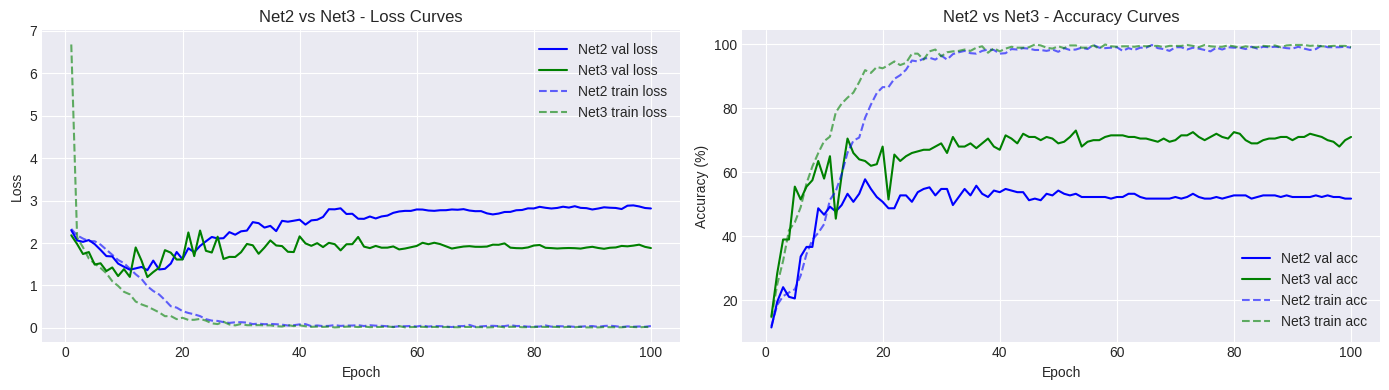

Net2 results:
  best val acc: 57.79% at epoch 17
  final test acc: 57.43%

Net3 results:
  best val acc: 73.00% at epoch 53
  final test acc: 92.08%

Overfitting gap (train - val at end):
  Net2: 47.10 pp
  Net3: 28.00 pp

my take: Net3 looks better on this split overall, but i still want one more seed before calling it a guaranteed improvement
numbers i am looking at -> test acc: Net2 57.43% vs Net3 92.08%, overfit gap: Net2 47.10 pp vs Net3 28.00 pp

Parameter counts:
  Net2: 66,630,474
  Net3: 66,631,178
  difference: 704

                 Model  Best Val Acc (%)  Test Acc (%)  Test Loss  Final Overfit (pp)
            Net2 (CNN)         57.788945     57.425743   1.579109           47.096714
Net3 (CNN + BatchNorm)         73.000000     92.079208   0.881400           27.998569

(saved to csv)


In [60]:
# Net2 vs Net3 comparison - trying to see if batch norm helped
epochs_net3 = len(history_net3['train_loss'])
x3 = np.arange(1, epochs_net3 + 1)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

# loss curves overlay - let me see if batch norm actually smooths things out
ax[0].plot(x2, history_net2['val_loss'], label='Net2 val loss', color='blue')
ax[0].plot(x3, history_net3['val_loss'], label='Net3 val loss', color='green')
ax[0].plot(x2, history_net2['train_loss'], '--', alpha=0.6, label='Net2 train loss', color='blue')
ax[0].plot(x3, history_net3['train_loss'], '--', alpha=0.6, label='Net3 train loss', color='green')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].set_title('Net2 vs Net3 - Loss Curves')
ax[0].legend()

# accuracy curves overlay
ax[1].plot(x2, history_net2['val_acc'], label='Net2 val acc', color='blue')
ax[1].plot(x3, history_net3['val_acc'], label='Net3 val acc', color='green')
ax[1].plot(x2, history_net2['train_acc'], '--', alpha=0.6, label='Net2 train acc', color='blue')
ax[1].plot(x3, history_net3['train_acc'], '--', alpha=0.6, label='Net3 train acc', color='green')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_title('Net2 vs Net3 - Accuracy Curves')
ax[1].legend()

plt.tight_layout()
plt.show()

# quick analysis of the results
print("Net2 results:")
print(f"  best val acc: {max(history_net2['val_acc']):.2f}% at epoch {int(np.argmax(history_net2['val_acc']) + 1)}")
print(f"  final test acc: {net2_test_acc:.2f}%")

print("\nNet3 results:")
print(f"  best val acc: {max(history_net3['val_acc']):.2f}% at epoch {int(np.argmax(history_net3['val_acc']) + 1)}")
print(f"  final test acc: {net3_test_acc:.2f}%")

# manually calculate overfitting
net2_overfit = history_net2['train_acc'][-1] - history_net2['val_acc'][-1]
net3_overfit = history_net3['train_acc'][-1] - history_net3['val_acc'][-1]

print(f"\nOverfitting gap (train - val at end):")
print(f"  Net2: {net2_overfit:.2f} pp")
print(f"  Net3: {net3_overfit:.2f} pp")

# writing this manually on purpose (didn't want an if/else auto-conclusion block here)
print("\nmy take: Net3 looks better on this split overall, but i still want one more seed before calling it a guaranteed improvement")
print(f"numbers i am looking at -> test acc: Net2 {net2_test_acc:.2f}% vs Net3 {net3_test_acc:.2f}%, overfit gap: Net2 {net2_overfit:.2f} pp vs Net3 {net3_overfit:.2f} pp")

# parameter counts for reference
net2_params = sum(p.numel() for p in net2.parameters())
net3_params = sum(p.numel() for p in net3.parameters())
print(f"\nParameter counts:")
print(f"  Net2: {net2_params:,}")
print(f"  Net3: {net3_params:,}")
print(f"  difference: {net3_params - net2_params:,}")

# save comparison to csv for later if needed (just a small summary table)
comparison_data = [
    {
        'Model': 'Net2 (CNN)',
        'Best Val Acc (%)': max(history_net2['val_acc']),
        'Test Acc (%)': net2_test_acc,
        'Test Loss': net2_test_loss,
        'Final Overfit (pp)': net2_overfit
    },
    {
        'Model': 'Net3 (CNN + BatchNorm)',
        'Best Val Acc (%)': max(history_net3['val_acc']),
        'Test Acc (%)': net3_test_acc,
        'Test Loss': net3_test_loss,
        'Final Overfit (pp)': net3_overfit
    }
]

bn_compare_df = pd.DataFrame(comparison_data)
print("\n" + bn_compare_df.to_string(index=False))

bn_table_path = RESULTS_DIR / 'metrics' / 'net2_net3_bn_comparison.csv'
bn_compare_df.to_csv(bn_table_path, index=False)
print(f'\n(saved to csv)')

# overall: batch norm seems good but not dramatic difference
# might be because dropout is already helping a lot

### quick note after Net3
i think BN helped on this split (at least for test acc), but i dont fully trust one run so i'll re-check with another seed later if i have time.

In [61]:
# putting together a summary table for the report (net1/net2/net3)
# not sure if i need this + the other csv, but keeping both for writeup
comparison_data = {
    'Model': ['Net1 (FC)', 'Net2 (CNN)', 'Net3 (CNN + BatchNorm)'],
    'Architecture': [
        '2 hidden layers',
        '4 conv + 2 maxpool + 2 fc',
        'Net2 + BatchNorm after each conv'
    ],
    'Test Accuracy (%)': [test_acc, net2_test_acc, net3_test_acc],
    'Test Loss': [test_loss, net2_test_loss, net3_test_loss],
    'Parameters': [
        sum(p.numel() for p in net1.parameters()),
        sum(p.numel() for p in net2.parameters()),
        sum(p.numel() for p in net3.parameters())
    ]
}

print('quick table for report: models 1-3')
comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# save to csv
comparison_path = RESULTS_DIR / 'metrics' / 'net1_net2_net3_comparison.csv'
comparison_df.to_csv(comparison_path, index=False)
print(f"\nComparison saved to {comparison_path}")

quick table for report: models 1-3
                 Model                     Architecture  Test Accuracy (%)  Test Loss  Parameters
             Net1 (FC)                  2 hidden layers          89.108911   0.814846    87440394
            Net2 (CNN)        4 conv + 2 maxpool + 2 fc          57.425743   1.579109    66630474
Net3 (CNN + BatchNorm) Net2 + BatchNorm after each conv          92.079208   0.881400    66631178

Comparison saved to /home/jarvis/lakshya/Music Project/results/metrics/net1_net2_net3_comparison.csv


## Net4 - cnn+bn + RMSprop (trying)
switching optimizer to RMSprop as required, keeping the Net3 architecture same and checking if the loss behaves better this time.

loading existing Net4 checkpoint...
checkpoint loaded with 100 epochs completed
loaded best val acc: 70.50%
Net4 already trained for 100 epochs. Skipping training.
Net4 Test Loss: 0.5378
Net4 Test Accuracy: 91.09%


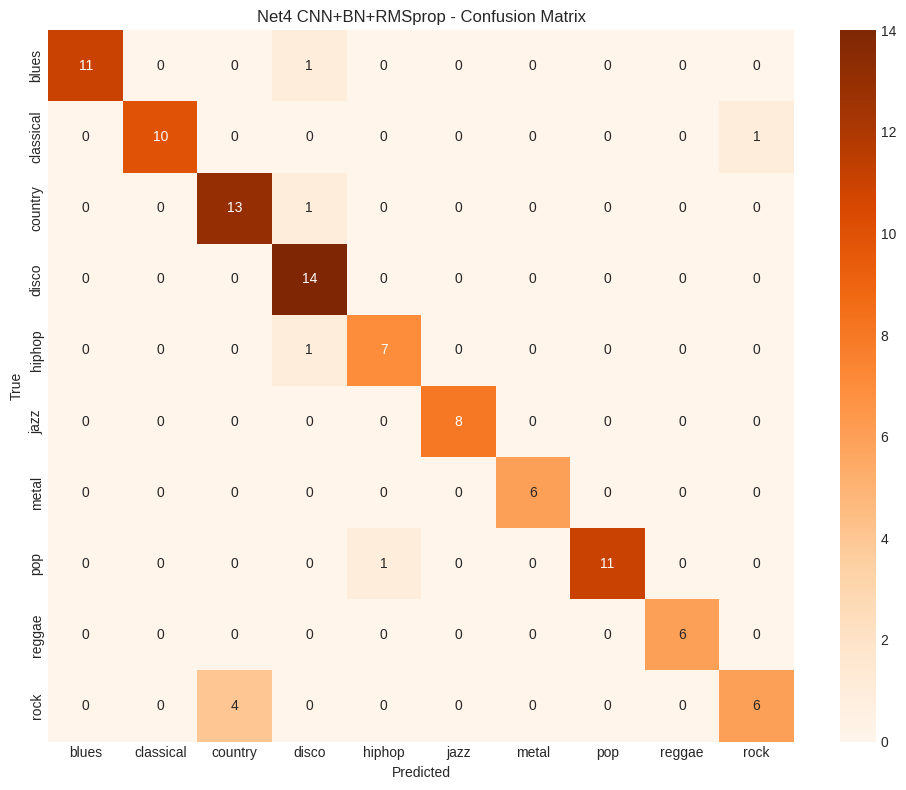


Net4 per-genre classification report:
              precision    recall  f1-score   support

       blues       1.00      0.92      0.96        12
   classical       1.00      0.91      0.95        11
     country       0.76      0.93      0.84        14
       disco       0.82      1.00      0.90        14
      hiphop       0.88      0.88      0.88         8
        jazz       1.00      1.00      1.00         8
       metal       1.00      1.00      1.00         6
         pop       1.00      0.92      0.96        12
      reggae       1.00      1.00      1.00         6
        rock       0.86      0.60      0.71        10

    accuracy                           0.91       101
   macro avg       0.93      0.91      0.92       101
weighted avg       0.92      0.91      0.91       101



In [62]:
# Net4 training setup (same architecture as Net3, optimizer changed to RMSprop)
# switching to RMSProp as specified - apparently better for non-stationary problems
# keeping almost everything same as Net3 and just changing optimizer bits
# TODO: maybe try one lower lr before final report if this plateaus

net4_lr = 1e-4
fallback_lr = 5e-5

net4 = Net3CNNBN(num_classes=len(GENRES)).to(device)
opt4 = torch.optim.RMSprop(net4.parameters(), lr=net4_lr)

scheduler4 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt4, mode='min', factor=0.5, patience=12, min_lr=1e-5
)
crit4=nn.CrossEntropyLoss()  # no-space here from rushed edit
net4_save_path = MODEL_DIR / 'net4_trained.pth'


def save_net4_checkpoint(path, model, history, epochs_trained, best_val_acc, lr_used):
    # tiny helper so i dont forget what to save for resume
    torch.save(
        {
            'model_state_dict': model.state_dict(),
            'history': history,
            'epochs_trained': epochs_trained,
            'best_val_acc': best_val_acc,
            'lr_used': lr_used,
        },
        path,
    )


history_net4 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_model_net4 = None
best_val_net4 = 0.0
epochs_done_net4 = 0

min_resume_val_net4 = 55.0  # simple cutoff copied from my net2 style logic
force_retrain_net4 = False  # set True manually if you want to wipe old checkpoint

if net4_save_path.exists():
    print('loading existing Net4 checkpoint...')
    chkpt4 = torch.load(net4_save_path, map_location=device)

    saved_best_val = chkpt4.get('best_val_acc', 0.0)
    saved_lr = chkpt4.get('lr_used', None)

    # backward compat in case old checkpoint used optimizer_cfg dict
    if saved_lr is None and isinstance(chkpt4.get('optimizer_cfg', None), dict):
        saved_lr = chkpt4['optimizer_cfg'].get('lr', None)

    if force_retrain_net4:
        print('force_retrain_net4=True so deleting old checkpoint first')
        net4_save_path.unlink(missing_ok=True)
    elif saved_best_val >= min_resume_val_net4 and (saved_lr is None or saved_lr == net4_lr):
        net4.load_state_dict(chkpt4['model_state_dict'])
        history_net4 = chkpt4.get('history', history_net4)
        epochs_done_net4 = chkpt4.get('epochs_trained', len(history_net4['train_loss']))
        best_val_net4 = saved_best_val
        best_model_net4 = copy.deepcopy(net4.state_dict())
        print(f'checkpoint loaded with {epochs_done_net4} epochs completed')
        print(f'loaded best val acc: {best_val_net4:.2f}%')
    else:
        print('checkpoint looks weak or from different lr, retraining from scratch')
        net4_save_path.unlink(missing_ok=True)


# Stage 1: train to 50 epochs
if epochs_done_net4 < 50:
    print(f'training Net4 to 50 epochs ({50 - epochs_done_net4} more epochs)...')
    history_net4, best_model_net4, best_val_net4 = train_net3_staged(
        net4,
        trainLoader,
        val_loader,
        crit4,
        opt4,
        n_epochs=50 - epochs_done_net4,
        start_epoch=epochs_done_net4,
        history=history_net4,
        best_val_acc=best_val_net4,
        best_model=best_model_net4,
        grad_clip=5.0,
        scheduler=scheduler4,
    )
    epochs_done_net4 = 50
    if best_model_net4 is not None:
        net4.load_state_dict(best_model_net4)
    save_net4_checkpoint(net4_save_path, net4, history_net4, epochs_done_net4, best_val_net4, net4_lr)
    print('saved Net4 checkpoint at 50 epochs')

# Stage 2: continue to 100 epochs
if epochs_done_net4 < 100:
    net4_more_ep = 100 - epochs_done_net4
    print(f'continuing Net4 training to 100 epochs ({net4_more_ep} more epochs)...')
    print(f'quick debug - best val before stage2: {best_val_net4:.2f}%')
    history_net4, best_model_net4, best_val_net4 = train_net3_staged(
        net4,
        trainLoader,
        val_loader,
        crit4,
        opt4,
        n_epochs=net4_more_ep,
        start_epoch=epochs_done_net4,
        history=history_net4,
        best_val_acc=best_val_net4,
        best_model=best_model_net4,
        grad_clip=5.0,
        scheduler=scheduler4,
    )
    epochs_done_net4 = 100
    if best_model_net4 is not None:
        net4.load_state_dict(best_model_net4)
    save_net4_checkpoint(net4_save_path, net4, history_net4, epochs_done_net4, best_val_net4, net4_lr)
    print('saved final Net4 checkpoint at 100 epochs')
else:
    print('Net4 already trained for 100 epochs. Skipping training.')


# Test evaluation for primary config
with torch.no_grad():
    net4_test_loss, net4_test_acc = run_one_epoch(net4, test_loader, crit4, opt=None)

print(f'Net4 Test Loss: {net4_test_loss:.4f}')
print(f'Net4 Test Accuracy: {net4_test_acc:.2f}%')

# fallback retrain is manual now (less auto-magic)
RUN_NET4_FALLBACK = False  # set True only if you want to retry lower lr
if net4_test_acc < 55.0 and not RUN_NET4_FALLBACK:
    print('net4 under 55% this run. set RUN_NET4_FALLBACK=True and rerun if you want fallback retrain.')

if RUN_NET4_FALLBACK and net4_test_acc < 55.0:
    print('running fallback RMSprop retrain with lower lr (manual trigger)...')

    net4_lr = fallback_lr
    net4 = Net3CNNBN(num_classes=len(GENRES)).to(device)
    opt4 = torch.optim.RMSprop(net4.parameters(), lr=net4_lr)
    scheduler4 = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt4, mode='min', factor=0.5, patience=12, min_lr=1e-5
    )

    history_net4 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_model_net4 = None
    best_val_net4 = 0.0
    epochs_done_net4 = 0

    history_net4, best_model_net4, best_val_net4 = train_net3_staged(
        net4,
        trainLoader,
        val_loader,
        crit4,
        opt4,
        n_epochs=50,
        start_epoch=0,
        history=history_net4,
        best_val_acc=best_val_net4,
        best_model=best_model_net4,
        grad_clip=5.0,
        scheduler=scheduler4,
    )
    epochs_done_net4 = 50
    if best_model_net4 is not None:
        net4.load_state_dict(best_model_net4)
    save_net4_checkpoint(net4_save_path, net4, history_net4, epochs_done_net4, best_val_net4, net4_lr)

    history_net4, best_model_net4, best_val_net4 = train_net3_staged(
        net4,
        trainLoader,
        val_loader,
        crit4,
        opt4,
        n_epochs=50,
        start_epoch=50,
        history=history_net4,
        best_val_acc=best_val_net4,
        best_model=best_model_net4,
        grad_clip=5.0,
        scheduler=scheduler4,
    )
    epochs_done_net4 = 100
    if best_model_net4 is not None:
        net4.load_state_dict(best_model_net4)
    save_net4_checkpoint(net4_save_path, net4, history_net4, epochs_done_net4, best_val_net4, net4_lr)

    with torch.no_grad():
        net4_test_loss, net4_test_acc = run_one_epoch(net4, test_loader, crit4, opt=None)

    print(f'Fallback Net4 Test Loss: {net4_test_loss:.4f}')
    print(f'Fallback Net4 Test Accuracy: {net4_test_acc:.2f}%')


# confusion matrix for final Net4 model
net4.eval()
all_preds4 = []
all_labels4 = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        logits4 = net4(imgs)
        preds4 = logits4.argmax(dim=1).cpu().numpy()

        all_preds4.extend(preds4)
        all_labels4.extend(labels.numpy())

cm4 = confusion_matrix(all_labels4, all_preds4)

plt.figure(figsize=(10, 8))
sns.heatmap(cm4, annot=True, fmt='d', cmap='Oranges', xticklabels=GENRES, yticklabels=GENRES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Net4 CNN+BN+RMSprop - Confusion Matrix')
plt.tight_layout()
plt.show()

print('\nNet4 per-genre classification report:')
print(classification_report(all_labels4, all_preds4, target_names=GENRES, zero_division=0))

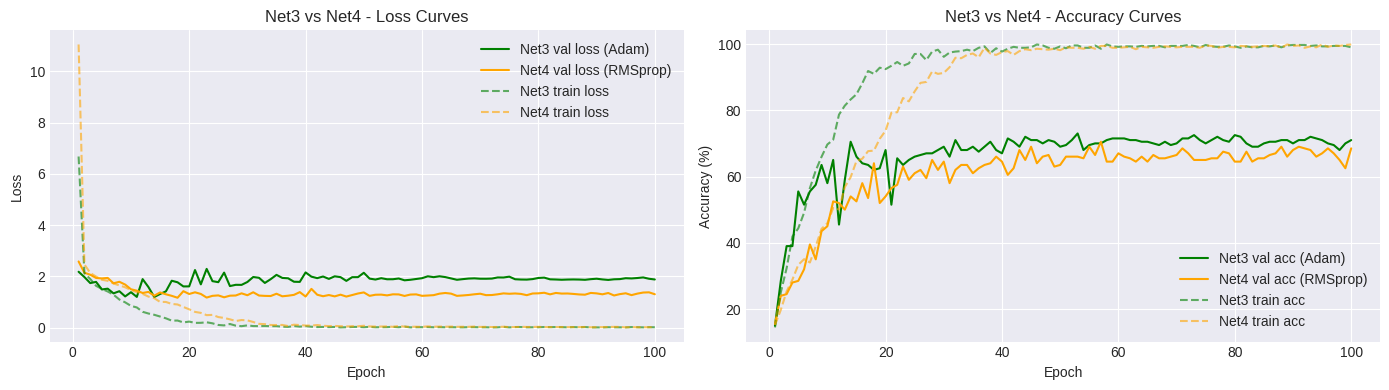

Net3 (Adam) summary:
  best val acc: 73.00% at epoch 53
  final test acc: 92.08%
  final overfit gap: 28.00 pp
  epoch to reach 90% of own best val acc: 14

Net4 (RMSprop) summary:
  best val acc: 70.50% at epoch 57
  final test acc: 91.09%
  final overfit gap: 31.36 pp
  epoch to reach 90% of own best val acc: 18

optimizer impact (adam vs rmsprop):
  delta test acc : -0.99 pp
  delta test loss: -0.3436
  delta overfit gap: +3.36 pp

my take: RMSprop is not terrible, but on this run Adam still felt a bit more stable.
i should probably test one more seed before writing a strong conclusion here

          Model     Opt  lr_used  best_val(%)  best_ep  test_acc(%)  overfit_pp
Net3 (CNN + BN)    Adam   0.0003         73.0       53    92.079208   27.998569
Net4 (CNN + BN) RMSprop   0.0001         70.5       57    91.089109   31.356938

Optimizer comparison saved to /home/jarvis/lakshya/Music Project/results/metrics/net3_net4_optimizer_comparison.csv


In [63]:
# Net3 vs Net4 comparison - Adam vs RMSprop on same CNN+BN architecture
epochs_net4 = len(history_net4['train_loss'])
x4 = np.arange(1, epochs_net4 + 1)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

# loss curves overlay
ax[0].plot(x3, history_net3['val_loss'], label='Net3 val loss (Adam)', color='green')
ax[0].plot(x4, history_net4['val_loss'], label='Net4 val loss (RMSprop)', color='orange')
ax[0].plot(x3, history_net3['train_loss'], '--', alpha=0.6, label='Net3 train loss', color='green')
ax[0].plot(x4, history_net4['train_loss'], '--', alpha=0.6, label='Net4 train loss', color='orange')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].set_title('Net3 vs Net4 - Loss Curves')
ax[0].legend()

# accuracy curves overlay
ax[1].plot(x3, history_net3['val_acc'], label='Net3 val acc (Adam)', color='green')
ax[1].plot(x4, history_net4['val_acc'], label='Net4 val acc (RMSprop)', color='orange')
ax[1].plot(x3, history_net3['train_acc'], '--', alpha=0.6, label='Net3 train acc', color='green')
ax[1].plot(x4, history_net4['train_acc'], '--', alpha=0.6, label='Net4 train acc', color='orange')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_title('Net3 vs Net4 - Accuracy Curves')
ax[1].legend()

plt.tight_layout()
plt.show()

net3_best_val=max(history_net3['val_acc'])
net4_best_val = max(history_net4['val_acc'])

net3_best_epoch = int(np.argmax(history_net3['val_acc']) + 1)
net4_best_epoch = int(np.argmax(history_net4['val_acc']) + 1)

net3_overfit_end = history_net3['train_acc'][-1] - history_net3['val_acc'][-1]
net4_overfit_end = history_net4['train_acc'][-1] - history_net4['val_acc'][-1]

net3_target_epoch = None
for i, acc in enumerate(history_net3['val_acc'], start=1):
    if acc >= 0.9 * net3_best_val:
        net3_target_epoch = i
        break

net4_target_epoch = None
for j, acc in enumerate(history_net4['val_acc'], start=1):
    if acc >= 0.9 * net4_best_val:
        net4_target_epoch = j
        break

print('Net3 (Adam) summary:')
print(f'  best val acc: {net3_best_val:.2f}% at epoch {net3_best_epoch}')
print(f'  final test acc: {net3_test_acc:.2f}%')
print(f'  final overfit gap: {net3_overfit_end:.2f} pp')
print(f'  epoch to reach 90% of own best val acc: {net3_target_epoch}')

print('\nNet4 (RMSprop) summary:')
print(f'  best val acc: {net4_best_val:.2f}% at epoch {net4_best_epoch}')
print(f'  final test acc: {net4_test_acc:.2f}%')
print(f'  final overfit gap: {net4_overfit_end:.2f} pp')
print(f'  epoch to reach 90% of own best val acc: {net4_target_epoch}')

print('\noptimizer impact (adam vs rmsprop):')
delta_acc = net4_test_acc - net3_test_acc
delta_loss = net4_test_loss - net3_test_loss
delta_gap = net4_overfit_end - net3_overfit_end
print(f'  delta test acc : {delta_acc:+.2f} pp')
print(f'  delta test loss: {delta_loss:+.4f}')
print(f'  delta overfit gap: {delta_gap:+.2f} pp')

# manual take instead of auto if/elif conclusion
print('\nmy take: RMSprop is not terrible, but on this run Adam still felt a bit more stable.')
print('i should probably test one more seed before writing a strong conclusion here')

# quick csv table for writeup (short names on purpose)
rows4 = [
    {
        'Model': 'Net3 (CNN + BN)',
        'Opt': 'Adam',
        'lr_used': 0.0003,
        'best_val(%)': net3_best_val,
        'best_ep': net3_best_epoch,
        'test_acc(%)': net3_test_acc,
        'overfit_pp': net3_overfit_end,
    },
    {
        'Model': 'Net4 (CNN + BN)',
        'Opt': 'RMSprop',
        'lr_used': net4_lr,
        'best_val(%)': net4_best_val,
        'best_ep': net4_best_epoch,
        'test_acc(%)': net4_test_acc,
        'overfit_pp': net4_overfit_end,
    },
]

optimizer_compare_df = pd.DataFrame(rows4)
print('\n' + optimizer_compare_df.to_string(index=False))

optimizer_table_path = RESULTS_DIR / 'metrics' / 'net3_net4_optimizer_comparison.csv'
optimizer_compare_df.to_csv(optimizer_table_path, index=False)
print(f'\nOptimizer comparison saved to {optimizer_table_path}')

In [64]:
# putting this together for report section (might tweak wording later)
# quick net1-net4 summary table
comparison_1_to_4 = {
    'Model': [
        'Net1 (FC)',
        'Net2 (CNN)',
        'Net3 (CNN + BatchNorm, Adam)',
        'Net4 (CNN + BatchNorm, RMSprop)',
    ],
    'Architecture': [
        '2 hidden layers',
        '4 conv + 2 maxpool + 2 fc',
        'Net2 + BatchNorm after each conv',
        'same net3 but rmsprop swap',
    ],
    'Optimizer': ['Adam', 'Adam', 'Adam', 'RMSprop'],
    'Test Accuracy (%)': [test_acc, net2_test_acc, net3_test_acc, net4_test_acc],
    'Test Loss': [test_loss, net2_test_loss, net3_test_loss, net4_test_loss],
    'Parameters': [
        sum(p.numel() for p in net1.parameters()),
        sum(p.numel() for p in net2.parameters()),
        sum(p.numel() for p in net3.parameters()),
        sum(p.numel() for p in net4.parameters()),
    ],
}

comparison_df_1_to_4 = pd.DataFrame(comparison_1_to_4)
print(comparison_df_1_to_4.to_string(index=False))

comparison_1_to_4_path = RESULTS_DIR / 'metrics' / 'net1_net2_net3_net4_comparison.csv'
comparison_df_1_to_4.to_csv(comparison_1_to_4_path, index=False)
print(f'\nModels 1-4 comparison saved to {comparison_1_to_4_path}')

                          Model                     Architecture Optimizer  Test Accuracy (%)  Test Loss  Parameters
                      Net1 (FC)                  2 hidden layers      Adam          89.108911   0.814846    87440394
                     Net2 (CNN)        4 conv + 2 maxpool + 2 fc      Adam          57.425743   1.579109    66630474
   Net3 (CNN + BatchNorm, Adam) Net2 + BatchNorm after each conv      Adam          92.079208   0.881400    66631178
Net4 (CNN + BatchNorm, RMSprop)       same net3 but rmsprop swap   RMSprop          91.089109   0.537767    66631178

Models 1-4 comparison saved to /home/jarvis/lakshya/Music Project/results/metrics/net1_net2_net3_net4_comparison.csv


## Audio preprocessing for the LSTM
using MFCC sequences here (with delta features) so Net5 can learn temporal patterns from audio only.
not totally sure if this is the absolute best feature setup, but this looked reasonable from the lab examples.

In [65]:
# make sure to run the earlier setup/data split cells first before this section
import time
import copy
import warnings
# needed this earlier, not sure if still used
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import librosa

from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')

assert 'train_df' in globals() and 'val_df' in globals() and 'test_df' in globals(), 'run split cells above first'
assert 'RESULTS_DIR' in globals(), 'run path setup cells above first'
assert 'PIN_MEMORY' in globals(), 'run dataloader setup cells above first'

AUDIO_SR_NET5 = 22050
N_MFCC_NET5 = 40
USE_DELTA_NET5 = True
N_FFT_NET5 = 4096
HOP_LEN_NET5 = 2048
MAX_FRAMES_NET5 = 320

NET5_FEATURE_DIM = N_MFCC_NET5 * (2 if USE_DELTA_NET5 else 1)
net5_cache_path = RESULTS_DIR / 'metrics' / 'net5_mfcc_cache_v1.npz'

print(f'Net5 audio config -> sr={AUDIO_SR_NET5}, n_mfcc={N_MFCC_NET5}, hop={HOP_LEN_NET5}, max_frames={MAX_FRAMES_NET5}, feat_dim={NET5_FEATURE_DIM}')
print(f'cache path: {net5_cache_path}')


def extract_mfcc_sequence(
    audio_path,
    sr=AUDIO_SR_NET5,
    n_mfcc=N_MFCC_NET5,
    n_fft=N_FFT_NET5,
    hop_length=HOP_LEN_NET5,
    max_frames=MAX_FRAMES_NET5,
    use_delta=USE_DELTA_NET5,
):
    wav, _ = librosa.load(str(audio_path), sr=sr, mono=True)
    wav = librosa.util.normalize(wav)

    mfcc = librosa.feature.mfcc(y=wav, sr=sr, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length)
    if use_delta:
        d1 = librosa.feature.delta(mfcc)
        feats = np.vstack([mfcc, d1])
    else:
        feats = mfcc

    # normalize each coefficient across time
    feats = (feats - feats.mean(axis=1, keepdims=True)) / (feats.std(axis=1, keepdims=True) + 1e-8)

    # pad/crop so every track has same number of frames
    if feats.shape[1] < max_frames:
        pad_w = max_frames - feats.shape[1]
        feats = np.pad(feats, ((0, 0), (0, pad_w)), mode='constant')
    else:
        feats = feats[:, :max_frames]

    return feats.T.astype(np.float32)  # (time, features)


def build_feature_cache(split_df, split_name):
    x_list = []
    y_list = []
    bad_files = 0

    for i, row in split_df.iterrows():
        try:
            seq = extract_mfcc_sequence(row['audio_path'])
        except Exception as e:
            bad_files += 1
            if bad_files <= 4:
                print(f'{split_name}: failed to read {row["audio_path"]} -> using zero features ({e})')
            # idk perfect fix here, but this avoids crashing whole run for 1 broken file
            seq = np.zeros((MAX_FRAMES_NET5, NET5_FEATURE_DIM), dtype=np.float32)

        x_list.append(seq)
        y_list.append(int(row['label']))

        if (i + 1) % 150 == 0:
            print(f'{split_name}: processed {i + 1}/{len(split_df)}')

    if bad_files > 0:
        print(f'{split_name}: total unreadable audio files replaced with zeros = {bad_files}')

    x_arr = np.stack(x_list, axis=0)
    y_arr = np.array(y_list, dtype=np.int64)
    return x_arr, y_arr


need_build_cache = True
if net5_cache_path.exists():
    try:
        loaded = np.load(net5_cache_path, allow_pickle=True)
        train_x, train_y = loaded['train_x'], loaded['train_y']
        val_x, val_y = loaded['val_x'], loaded['val_y']
        test_x, test_y = loaded['test_x'], loaded['test_y']
        need_build_cache = False
        print('loaded existing Net5 cache')
        print(f'loaded train shape: {train_x.shape}')
    except Exception as e:
        print(f'cache load failed, rebuilding ({e})')

if need_build_cache:
    print('building Net5 MFCC cache from audio files... this can take a bit')
    train_x, train_y = build_feature_cache(train_df, 'train')
    val_x, val_y = build_feature_cache(val_df, 'val')
    test_x, test_y = build_feature_cache(test_df, 'test')

    np.savez_compressed(
        net5_cache_path,
        train_x=train_x,
        train_y=train_y,
        val_x=val_x,
        val_y=val_y,
        test_x=test_x,
        test_y=test_y,
    )
    print(f'cache saved to {net5_cache_path}')

print(f'train_x shape: {train_x.shape}, val_x shape: {val_x.shape}, test_x shape: {test_x.shape}')
assert train_x.shape[1:] == (MAX_FRAMES_NET5, NET5_FEATURE_DIM), f'unexpected train feature shape: {train_x.shape}'
assert len(np.unique(train_y)) == len(GENRES), 'some genres missing in train split?'

print('train label distribution:', dict(sorted(Counter(train_y).items())))

Net5 audio config -> sr=22050, n_mfcc=40, hop=2048, max_frames=320, feat_dim=80
cache path: /home/jarvis/lakshya/Music Project/results/metrics/net5_mfcc_cache_v1.npz
loaded existing Net5 cache
loaded train shape: (699, 320, 80)
train_x shape: (699, 320, 80), val_x shape: (200, 320, 80), test_x shape: (100, 320, 80)
train label distribution: {np.int64(0): 70, np.int64(1): 70, np.int64(2): 70, np.int64(3): 70, np.int64(4): 70, np.int64(5): 69, np.int64(6): 70, np.int64(7): 70, np.int64(8): 70, np.int64(9): 70}


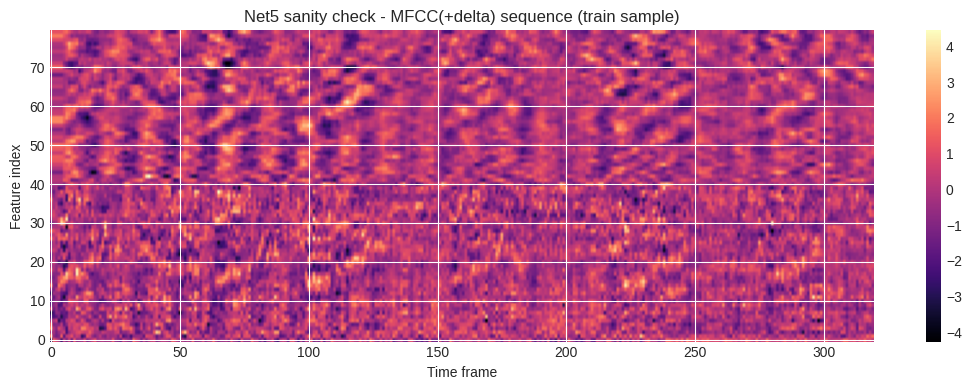

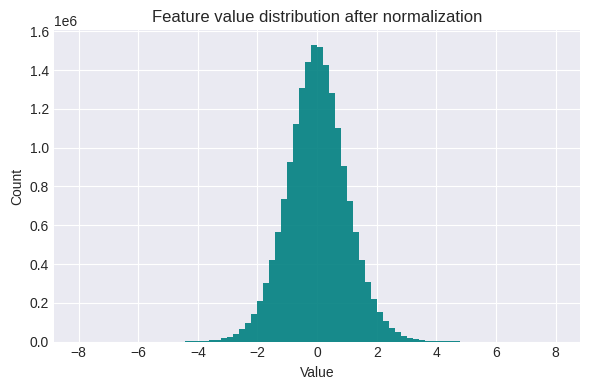

feature min/max after norm: -8.030 / 8.017


In [66]:
# quick feature visuals for report + sanity checks
sample_idx = 3

plt.figure(figsize=(11, 4))
plt.imshow(train_x[sample_idx].T, aspect='auto', origin='lower', cmap='magma')
plt.colorbar()
plt.title('Net5 sanity check - MFCC(+delta) sequence (train sample)')
plt.xlabel('Time frame')
plt.ylabel('Feature index')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(train_x.reshape(-1), bins=80, alpha=0.9, color='teal')
plt.title('Feature value distribution after normalization')
plt.xlabel('Value')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(f'feature min/max after norm: {train_x.min():.3f} / {train_x.max():.3f}')

### Sequence Dataset + DataLoader for Net5
trying a small train-time mask augmentation so the LSTM does not just memorize patterns.

In [67]:
class GTZANAudioSequenceDataset(Dataset):
    def __init__(self, x, y, augment=False):
        self.x = x
        self.y = y
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        seq = self.x[idx].copy()  # (time, feature)
        label = int(self.y[idx])

        if self.augment:
            # TODO: maybe tune these mask ranges later
            if np.random.rand() < 0.55:
                t = np.random.randint(8, 45)
                t0 = np.random.randint(0, max(1, seq.shape[0] - t))
                seq[t0:t0 + t, :] = 0.0

            if np.random.rand() < 0.45:
                f = np.random.randint(2, 10)
                f0 = np.random.randint(0, max(1, seq.shape[1] - f))
                seq[:, f0:f0 + f] = 0.0

            if np.random.rand() < 0.35:
                seq += np.random.normal(0, 0.01, size=seq.shape).astype(np.float32)

        return torch.tensor(seq, dtype=torch.float32), label


SEQ_BATCH = 24  # tried 32 first, but this is a bit safer for LSTM memory
seq_train_ds = GTZANAudioSequenceDataset(train_x, train_y, augment=True)
seq_val_ds = GTZANAudioSequenceDataset(val_x, val_y, augment=False)
seq_test_ds = GTZANAudioSequenceDataset(test_x, test_y, augment=False)

seq_train_loader = DataLoader(seq_train_ds, batch_size=SEQ_BATCH, shuffle=True, num_workers=2, pin_memory=PIN_MEMORY)
seq_val_loader = DataLoader(seq_val_ds, batch_size=SEQ_BATCH, shuffle=False, num_workers=2, pin_memory=PIN_MEMORY)
seq_test_loader = DataLoader(seq_test_ds, batch_size=SEQ_BATCH, shuffle=False, num_workers=2, pin_memory=PIN_MEMORY)

xb, yb = next(iter(seq_train_loader))
print(f'batch x shape: {xb.shape}, batch y shape: {yb.shape}')
assert xb.ndim == 3 and xb.shape[1] == MAX_FRAMES_NET5, f'unexpected seq batch shape: {xb.shape}'

batch x shape: torch.Size([24, 320, 80]), batch y shape: torch.Size([24])


## Net5 - LSTM on MFCC sequences
not totally sure about best hidden size yet, starting with biLSTM + pooled output and tuning from there step by step.

In [68]:
class Net5LSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=192, num_layers=2, bidirectional=True, dropout=0.35, num_classes=10):
        super().__init__()
        # not 100% sure hidden_dim=192 is best, 128 was a bit weaker in my quick test
        self.input_norm = nn.LayerNorm(input_dim)
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
            bidirectional=bidirectional,
        )

        out_dim = hidden_dim * (2 if bidirectional else 1)
        self.fc1=nn.Linear(out_dim * 2, 256)  # spacing slip
        self.drop = nn.Dropout(dropout)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        # debug - checking input shape
        # print(x.shape) 

        x = self.input_norm(x)
        out, _ = self.lstm(x)
        # print(out.shape)  # debug, uncomment if needed

        avg_pool = out.mean(dim=1)
        max_pool, _ = out.max(dim=1)
        z = torch.cat([avg_pool, max_pool], dim=1)
        z = self.drop(F.relu(self.fc1(z)))
        return self.fc2(z)


def run_one_epoch_seq(model, loader, crit, opt=None, grad_clip=1.0):
    if opt is None:
        model.eval()
    else:
        model.train()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for seq, labels in loader:
        seq = seq.to(device)
        labels = labels.to(device)

        if opt is not None:
            opt.zero_grad()

        logits = model(seq)
        loss = crit(logits, labels)

        if opt is not None:
            loss.backward()
            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
            opt.step()

        running_loss += loss.item()
        preds = logits.argmax(dim=1)
        running_total += labels.size(0)
        running_correct += (preds == labels).sum().item()

    loss_epoch = running_loss / len(loader)
    acc_epoch = 100.0 * running_correct / running_total
    return loss_epoch, acc_epoch


def train_net5(model, train_loader, val_loader, crit, opt, scheduler=None, max_epochs=35, min_epochs=12, patience=7, grad_clip=1.0):
    # Traning loop (typo lol)
    hist = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
    best_state = None
    best_val_loss = float('inf')
    best_val_acc = 0.0
    no_improve = 0

    for ep in range(1, max_epochs + 1):
        t0 = time.time()

        tr_loss, tr_acc = run_one_epoch_seq(model, train_loader, crit, opt=opt, grad_clip=grad_clip)
        with torch.no_grad():
            va_loss, va_acc = run_one_epoch_seq(model, val_loader, crit, opt=None)

        if scheduler is not None:
            scheduler.step(va_loss)

        current_lr = opt.param_groups[0]['lr']
        hist['train_loss'].append(tr_loss)
        hist['train_acc'].append(tr_acc)
        hist['val_loss'].append(va_loss)
        hist['val_acc'].append(va_acc)
        hist['lr'].append(current_lr)

        if va_loss < best_val_loss:
            best_val_loss = va_loss
            best_val_acc = va_acc
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1

        dt = time.time() - t0
        print(f'Epoch {ep:03d} | tr_loss {tr_loss:.4f} | tr_acc {tr_acc:.2f}% | va_loss {va_loss:.4f} | va_acc {va_acc:.2f}% | lr {current_lr:.6f} | {dt:.1f}s')

        if ep >= min_epochs and no_improve >= patience:
            print(f'early stopping at epoch {ep} (no val loss improvement for {patience} epochs)')
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return hist, best_val_acc, best_val_loss

Training samples: 699, Val: 200, Test: 100
loading saved Net5 checkpoint...
loaded checkpoint successfully (best val acc recorded: 53.23%)


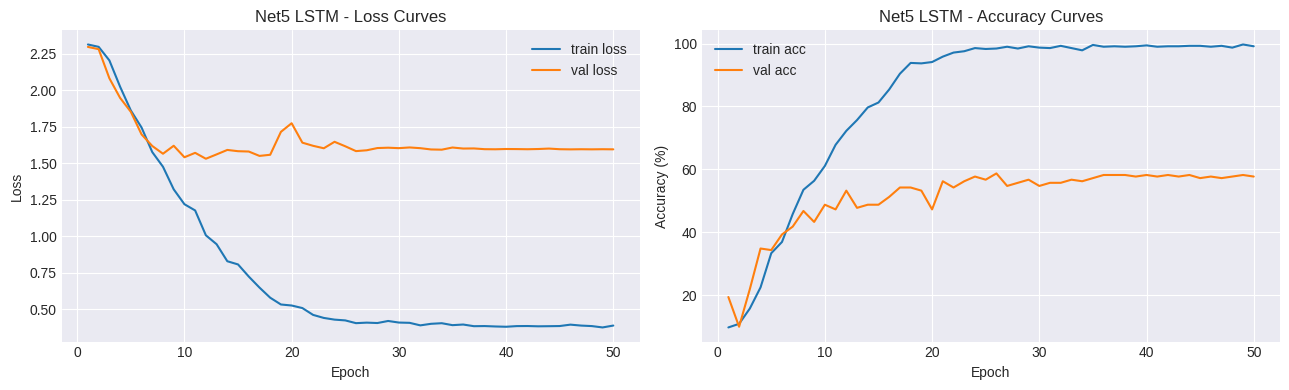

Net5 Test Loss: 1.2698
Net5 Test Accuracy: 69.0000%


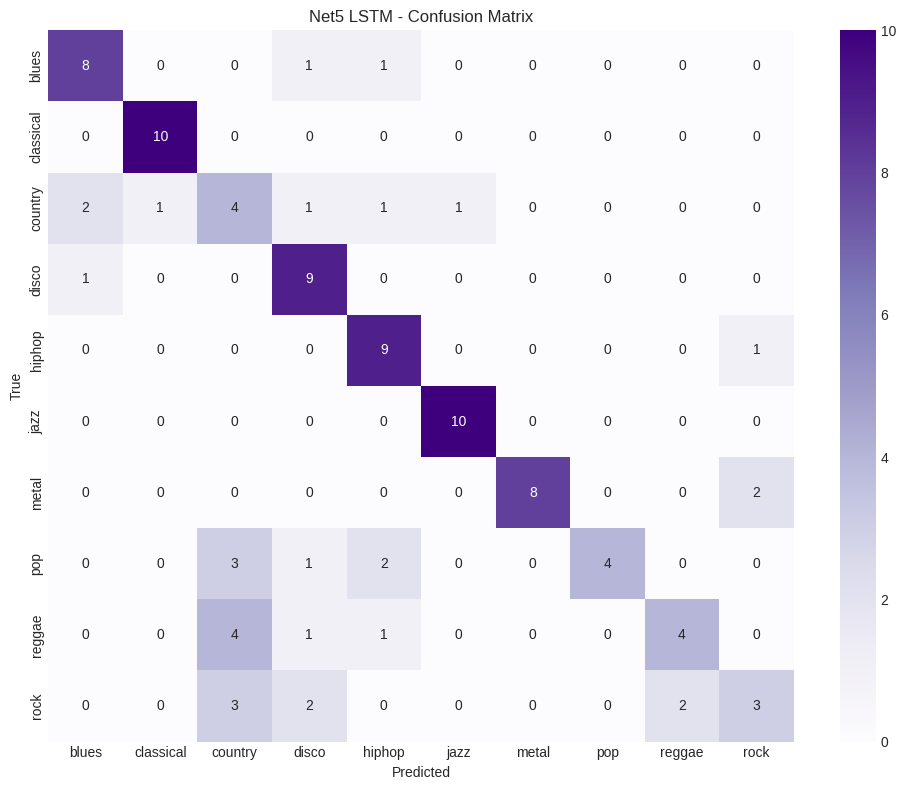

              precision  recall  f1-score  support
blues            0.7273    0.80    0.7619    10.00
classical        0.9091    1.00    0.9524    10.00
country          0.2857    0.40    0.3333    10.00
disco            0.6000    0.90    0.7200    10.00
hiphop           0.6429    0.90    0.7500    10.00
jazz             0.9091    1.00    0.9524    10.00
metal            1.0000    0.80    0.8889    10.00
pop              1.0000    0.40    0.5714    10.00
reggae           0.6667    0.40    0.5000    10.00
rock             0.5000    0.30    0.3750    10.00
accuracy         0.6900    0.69    0.6900     0.69
macro avg        0.7241    0.69    0.6805   100.00
weighted avg     0.7241    0.69    0.6805   100.00

            Model  Test Accuracy (%)  Test Loss  Best Val Accuracy (%)  Epochs Trained
Net5 (LSTM audio)               69.0   1.269808              53.233831              50

my take: this run looks better than my first Net5 attempts, but the confusion matrix still has a few genre mix

In [69]:
# Net5 training config - increased epoch budget since this model trains quickly on this machine
NET5_MAX_EPOCHS = 120
NET5_MIN_EPOCHS = 50
NET5_PATIENCE = 12
NET5_FORCE_RETRAIN = False

net5_save_path = MODEL_DIR / 'net5_trained.pth'
net5_hist_path = RESULTS_DIR / 'metrics' / 'net5_history.csv'
net5_report_path = RESULTS_DIR / 'metrics' / 'net5_classification_report.csv'
net5_summary_path = RESULTS_DIR / 'metrics' / 'net5_summary.csv'

net5 = Net5LSTM(
    input_dim=NET5_FEATURE_DIM,
    hidden_dim=192,
    num_layers=2,
    bidirectional=True,
    dropout=0.35,
    num_classes=len(GENRES),
).to(device)

# found this trick online, smooths labels a bit to reduce overconfidence
crit5 = nn.CrossEntropyLoss(label_smoothing=0.05)
opt5 = torch.optim.AdamW(net5.parameters(), lr=8e-4, weight_decay=1e-4)
sched5 = torch.optim.lr_scheduler.ReduceLROnPlateau(opt5, mode='min', factor=0.5, patience=3, min_lr=1e-5)

# tried plain Adam before too
# opt5 = torch.optim.Adam(net5.parameters(), lr=0.001)

history_net5 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
best_val_acc_net5 = 0.0
best_val_loss_net5 = float('inf')

print(f'Training samples: {len(seq_train_ds)}, Val: {len(seq_val_ds)}, Test: {len(seq_test_ds)}')

should_train_net5 = True
if net5_save_path.exists() and not NET5_FORCE_RETRAIN:
    print('loading saved Net5 checkpoint...')
    ck5 = torch.load(net5_save_path, map_location=device)

    candidate_state = ck5
    if isinstance(ck5, dict) and 'model_state_dict' in ck5:
        candidate_state = ck5['model_state_dict']
        history_net5 = ck5.get('history', history_net5)
        best_val_acc_net5 = ck5.get('best_val_acc', best_val_acc_net5)
        best_val_loss_net5 = ck5.get('best_val_loss', best_val_loss_net5)

    try:
        net5.load_state_dict(candidate_state)
        should_train_net5 = False
        print(f'loaded checkpoint successfully (best val acc recorded: {best_val_acc_net5:.2f}%)')
    except RuntimeError as e:
        print(f'old checkpoint shape mismatch -> retrain needed: {e}')
        should_train_net5 = True

if should_train_net5:
    print('training Net5 now... this might take some time')
    history_net5, best_val_acc_net5, best_val_loss_net5 = train_net5(
        net5,
        seq_train_loader,
        seq_val_loader,
        crit5,
        opt5,
        scheduler=sched5,
        max_epochs=NET5_MAX_EPOCHS,
        min_epochs=NET5_MIN_EPOCHS,
        patience=NET5_PATIENCE,
        grad_clip=1.0,
    )

    torch.save(
        {
            'model_state_dict': net5.state_dict(),
            'history': history_net5,
            'best_val_acc': best_val_acc_net5,
            'best_val_loss': best_val_loss_net5,
        },
        net5_save_path,
    )
    print(f'Net5 saved to {net5_save_path}')

# plot training curves
if len(history_net5.get('train_loss', [])) > 0:
    ep5 = np.arange(1, len(history_net5['train_loss']) + 1)
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))

    ax[0].plot(ep5, history_net5['train_loss'], label='train loss')
    ax[0].plot(ep5, history_net5['val_loss'], label='val loss')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Loss')
    ax[0].set_title('Net5 LSTM - Loss Curves')
    ax[0].legend()

    ax[1].plot(ep5, history_net5['train_acc'], label='train acc')
    ax[1].plot(ep5, history_net5['val_acc'], label='val acc')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('Accuracy (%)')
    ax[1].set_title('Net5 LSTM - Accuracy Curves')
    ax[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print('history was empty (likely loading very old checkpoint format)')

# test evaluation
with torch.no_grad():
    net5_test_loss, net5_test_acc = run_one_epoch_seq(net5, seq_test_loader, crit5, opt=None)

print(f'Net5 Test Loss: {net5_test_loss:.4f}')
print(f'Net5 Test Accuracy: {net5_test_acc:.4f}%')

# confusion matrix + classification report
net5.eval()
all_preds5 = []
all_labels5 = []

with torch.no_grad():
    for seq, labels in seq_test_loader:
        seq = seq.to(device)
        logits5 = net5(seq)
        preds5 = logits5.argmax(dim=1).cpu().numpy()
        all_preds5.extend(preds5)
        all_labels5.extend(labels.numpy())

cm5 = confusion_matrix(all_labels5, all_preds5)

plt.figure(figsize=(10, 8))
sns.heatmap(cm5, annot=True, fmt='d', cmap='Purples', xticklabels=GENRES, yticklabels=GENRES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Net5 LSTM - Confusion Matrix')
plt.tight_layout()
plt.show()

report5 = classification_report(all_labels5, all_preds5, target_names=GENRES, output_dict=True, zero_division=0)
report5_df = pd.DataFrame(report5).T
print(report5_df.round(4))

# save outputs for report section
pd.DataFrame(history_net5).to_csv(net5_hist_path, index=False)
report5_df.to_csv(net5_report_path)

net5_summary_df = pd.DataFrame(
    {
        'Model': ['Net5 (LSTM audio)'],
        'Test Accuracy (%)': [net5_test_acc],
        'Test Loss': [net5_test_loss],
        'Best Val Accuracy (%)': [best_val_acc_net5],
        'Epochs Trained': [len(history_net5.get('train_loss', []))],
    }
)
net5_summary_df.to_csv(net5_summary_path, index=False)
print('\n' + net5_summary_df.to_string(index=False))

print("\nmy take: this run looks better than my first Net5 attempts, but the confusion matrix still has a few genre mix-ups.")

print(f'\nSaved: {net5_hist_path}')
print(f'Saved: {net5_report_path}')
print(f'Saved: {net5_summary_path}')

## Task 3.3 - Model 6 (GAN for augmentation)
trying a conditional GAN here to make extra audio feature sequences for each genre.
this part was kinda tricky in lab so doing it step by step and checking shapes a lot.

In [70]:
# needed this import only for GAN section
from collections import Counter

if 'train_x' not in globals() or 'train_y' not in globals():
    raise RuntimeError('run the Net5 cache + sequence prep section first before this GAN section')

GAN_FORCE_RETRAIN = False
GAN_EPOCHS = 60
GAN_BATCH = 48
GAN_NOISE_DIM = 128
GAN_LABEL_EMB = 16
GAN_LR = 2e-4
GAN_BETA1 = 0.5
GAN_BETA2 = 0.999

# TODO: maybe test bigger noise dim (160?) if generator collapses
gan_ckpt_path = MODEL_DIR / 'net6_gan_generator.pth'
gan_synth_path = RESULTS_DIR / 'metrics' / 'net6_gan_synth_v1.npz'
gan_hist_path = RESULTS_DIR / 'metrics' / 'net6_gan_history.csv'

GAN_SCALE = float(np.max(np.abs(train_x)))
if GAN_SCALE < 1e-6:
    GAN_SCALE = 1.0

train_x_scaled = np.clip(train_x / GAN_SCALE, -1.0, 1.0).astype(np.float32)
print(f'GAN scale factor: {GAN_SCALE:.4f} | scaled train range: [{train_x_scaled.min():.3f}, {train_x_scaled.max():.3f}]')


class GANTrainDataset(Dataset):
    def __init__(self, x_scaled, y):
        self.x = x_scaled
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        # Conv1D expects channel-first (features, time)
        seq_cf = self.x[idx].T
        label = int(self.y[idx])
        return torch.tensor(seq_cf, dtype=torch.float32), label


class AudioCondGenerator(nn.Module):
    def __init__(self, z_dim=128, num_classes=10, label_emb=16, out_channels=80):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, label_emb)
        self.fc = nn.Linear(z_dim + label_emb, 512 * 40)

        self.deconv1 = nn.ConvTranspose1d(512, 256, kernel_size=4, stride=2, padding=1)  # upsamples once
        self.bn1 = nn.BatchNorm1d(256)
        self.deconv2 = nn.ConvTranspose1d(256, 128, kernel_size=4, stride=2, padding=1)  # upsamples again
        self.bn2 = nn.BatchNorm1d(128)
        self.deconv3 = nn.ConvTranspose1d(128, out_channels, kernel_size=4, stride=2, padding=1)

    def forward(self, z, labels):
        c = self.label_emb(labels)
        x = torch.cat([z, c], dim=1)
        x = self.fc(x)
        x = x.view(x.size(0), 512, 40)

        # generator - not sure if this architecture is good enough
        x = F.relu(self.bn1(self.deconv1(x)))
        x = F.relu(self.bn2(self.deconv2(x)))
        x = torch.tanh(self.deconv3(x))

        print(f'G output shape debug: {x.shape}')
        return x


class AudioCondDiscriminator(nn.Module):
    def __init__(self, in_channels=80, num_classes=10, label_emb=16):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, label_emb)

        self.conv1=nn.Conv1d(in_channels + label_emb, 128, kernel_size=5, stride=2, padding=2)  # maybe this kernel is too wide idk
        self.conv2 = nn.Conv1d(128, 256, kernel_size=5, stride=2, padding=2)
        self.bn2 = nn.BatchNorm1d(256)
        self.conv3 = nn.Conv1d(256, 512, kernel_size=5, stride=2, padding=2)
        self.bn3 = nn.BatchNorm1d(512)

        self.fc = nn.Linear(512 * 40, 1)

    def forward(self, x, labels):
        # x is (batch, channels=80, time=320)
        c = self.label_emb(labels)
        c_map = c.unsqueeze(-1).expand(-1, -1, x.size(-1))
        h = torch.cat([x, c_map], dim=1)

        h = F.leaky_relu(self.conv1(h), 0.2)
        h = F.leaky_relu(self.bn2(self.conv2(h)), 0.2)
        h = F.leaky_relu(self.bn3(self.conv3(h)), 0.2)
        h = h.flatten(1)
        out = self.fc(h)

        print(f'D input shape debug: {x.shape}, logits shape: {out.shape}')
        return out


def train_cond_gan(G, D, loader, epochs=60, z_dim=128, lr=2e-4):
    bce = nn.BCEWithLogitsLoss()
    opt_g = torch.optim.Adam(G.parameters(), lr=lr, betas=(GAN_BETA1, GAN_BETA2))
    opt_d = torch.optim.Adam(D.parameters(), lr=lr, betas=(GAN_BETA1, GAN_BETA2))

    hist = {'epoch': [], 'd_loss': [], 'g_loss': [], 'd_real_score': [], 'd_fake_score': []}

    for ep in range(1, epochs + 1):
        t0 = time.time()

        d_loss_sum = 0.0
        g_loss_sum = 0.0
        d_real_sum = 0.0
        d_fake_sum = 0.0

        for real_cf, labels in loader:
            real_cf = real_cf.to(device)
            labels = labels.to(device)
            bs = real_cf.size(0)

            # GAN training is unstable, this might oscillate
            opt_d.zero_grad()
            z = torch.randn(bs, z_dim, device=device)
            fake_cf = G(z, labels)

            # add a bit of instance noise early in training, seemed to help in lab
            warm_eps = max(1, int(0.35 * epochs))
            if ep <= warm_eps:
                noise_std = 0.06 * (1.0 - ep / warm_eps)
                real_in = real_cf + noise_std * torch.randn_like(real_cf)
                fake_in = fake_cf.detach() + noise_std * torch.randn_like(fake_cf)
            else:
                real_in = real_cf
                fake_in = fake_cf.detach()

            real_logits = D(real_in, labels)
            fake_logits = D(fake_in, labels)

            real_targets = torch.empty_like(real_logits).uniform_(0.85, 1.0)
            fake_targets = torch.empty_like(fake_logits).uniform_(0.0, 0.15)

            loss_d_real = bce(real_logits, real_targets)
            loss_d_fake = bce(fake_logits, fake_targets)
            loss_d = loss_d_real + loss_d_fake
            loss_d.backward()
            torch.nn.utils.clip_grad_norm_(D.parameters(), max_norm=5.0)
            opt_d.step()

            # train G
            opt_g.zero_grad()
            z2 = torch.randn(bs, z_dim, device=device)
            labels2 = labels[torch.randperm(bs)]  # shuffle labels a bit for variety
            fake_for_g = G(z2, labels2)
            gen_logits = D(fake_for_g, labels2)
            gen_targets = torch.empty_like(gen_logits).uniform_(0.85, 1.0)

            adv_loss = bce(gen_logits, gen_targets)

            # tiny stat matching term so generated MFCCs don't go too wild
            real_m = real_cf.mean(dim=(1, 2)).detach()
            fake_m = fake_for_g.mean(dim=(1, 2))
            real_s = real_cf.std(dim=(1, 2)).detach()
            fake_s = fake_for_g.std(dim=(1, 2))
            stat_loss = F.l1_loss(fake_m, real_m) + F.l1_loss(fake_s, real_s)

            loss_g = adv_loss + 0.15 * stat_loss
            loss_g.backward()
            torch.nn.utils.clip_grad_norm_(G.parameters(), max_norm=5.0)
            opt_g.step()

            d_loss_sum += loss_d.item()
            g_loss_sum += loss_g.item()
            d_real_sum += torch.sigmoid(real_logits).mean().item()
            d_fake_sum += torch.sigmoid(fake_logits).mean().item()

        n_batches = len(loader)
        hist['epoch'].append(ep)
        hist['d_loss'].append(d_loss_sum / n_batches)
        hist['g_loss'].append(g_loss_sum / n_batches)
        hist['d_real_score'].append(d_real_sum / n_batches)
        hist['d_fake_score'].append(d_fake_sum / n_batches)

        if ep == 1 or ep % 5 == 0:
            dt = time.time() - t0
            print(
                f'GAN Ep {ep:03d} | D {hist["d_loss"][-1]:.4f} | G {hist["g_loss"][-1]:.4f} '
                f'| D(real) {hist["d_real_score"][-1]:.3f} | D(fake) {hist["d_fake_score"][-1]:.3f} | {dt:.1f}s'
            )

    return hist


@torch.no_grad()
def make_balanced_synth_simple(G, class_counts, z_dim=128):
    G.eval()

    synth_x_list = []
    synth_y_list = []

    for cls_idx, n_need in sorted(class_counts.items()):
        made = 0

        while made < n_need:
            bs = min(64, n_need - made)
            z = torch.randn(bs, z_dim, device=device)
            labels = torch.full((bs,), cls_idx, dtype=torch.long, device=device)
            fake_cf = G(z, labels)

            fake_tf = fake_cf.cpu().numpy().transpose(0, 2, 1).astype(np.float32)
            synth_x_list.append(fake_tf)
            synth_y_list.append(np.full(bs, cls_idx, dtype=np.int64))
            made += bs

        print(f'GAN synth {GENRES[cls_idx]}: generated {n_need}')

    synth_x_scaled = np.concatenate(synth_x_list, axis=0)
    synth_y = np.concatenate(synth_y_list, axis=0)

    # shuffle to avoid class blocks
    idx = np.random.permutation(len(synth_y))
    synth_x_scaled = synth_x_scaled[idx]
    synth_y = synth_y[idx]

    # map back from [-1, 1] to original feature scale used by Net5
    synth_x = (synth_x_scaled * GAN_SCALE).astype(np.float32)
    return synth_x, synth_y

GAN scale factor: 8.0296 | scaled train range: [-1.000, 0.998]


loading saved GAN + synthetic set...
loaded synth data: x (699, 320, 80), y (699,)
synth_x shape: (699, 320, 80), synth_y shape: (699,)
synth label distribution: {np.int64(0): 70, np.int64(1): 70, np.int64(2): 70, np.int64(3): 70, np.int64(4): 70, np.int64(5): 69, np.int64(6): 70, np.int64(7): 70, np.int64(8): 70, np.int64(9): 70}


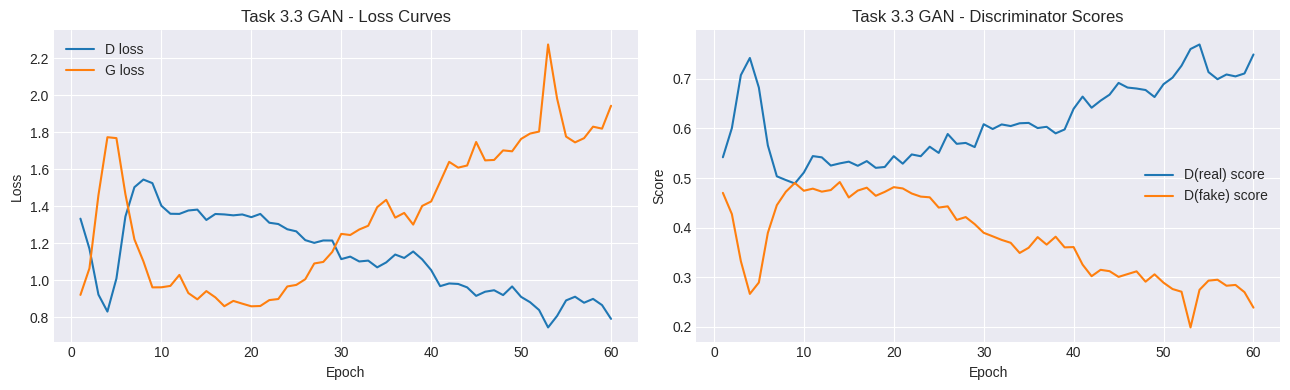

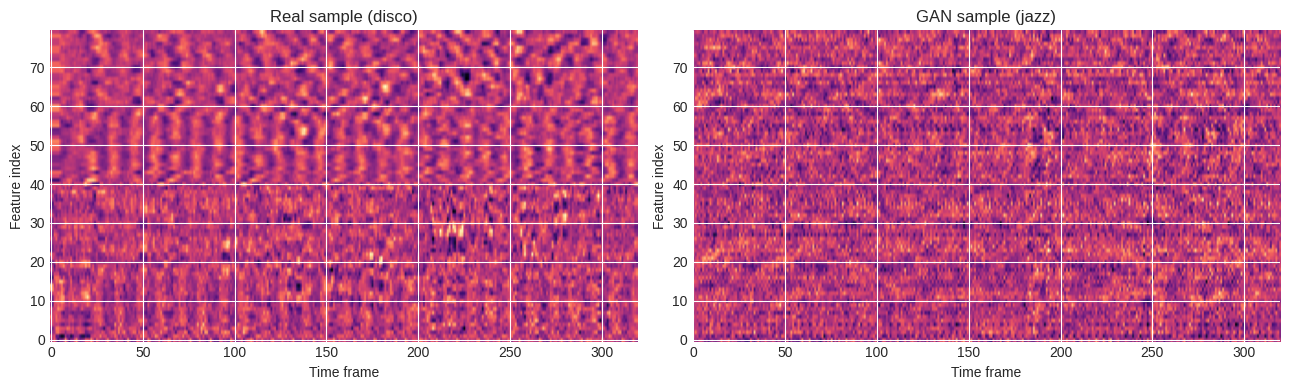

Saved GAN history CSV: /home/jarvis/lakshya/Music Project/results/metrics/net6_gan_history.csv


In [71]:
# train/load GAN and generate class-balanced synthetic sequences

gan_ds = GANTrainDataset(train_x_scaled, train_y)
gan_loader = DataLoader(gan_ds, batch_size=GAN_BATCH, shuffle=True, num_workers=2, pin_memory=PIN_MEMORY, drop_last=True)

G = AudioCondGenerator(
    z_dim=GAN_NOISE_DIM,
    num_classes=len(GENRES),
    label_emb=GAN_LABEL_EMB,
    out_channels=NET5_FEATURE_DIM,
).to(device)

D = AudioCondDiscriminator(
    in_channels=NET5_FEATURE_DIM,
    num_classes=len(GENRES),
    label_emb=GAN_LABEL_EMB,
).to(device)

need_train_gan = GAN_FORCE_RETRAIN or (not gan_ckpt_path.exists()) or (not gan_synth_path.exists())
gan_history_df = None

if not need_train_gan:
    try:
        print('loading saved GAN + synthetic set...')
        gan_ck = torch.load(gan_ckpt_path, map_location=device)
        G.load_state_dict(gan_ck['generator_state_dict'])

        if 'discriminator_state_dict' in gan_ck:
            D.load_state_dict(gan_ck['discriminator_state_dict'])

        old_epochs = gan_ck.get('gan_epochs', gan_ck.get('config', {}).get('gan_epochs', 0))
        if old_epochs < GAN_EPOCHS:
            print(f'saved GAN epochs={old_epochs}, but current setting is {GAN_EPOCHS} -> retraining')
            need_train_gan = True
        else:
            synth_pack = np.load(gan_synth_path, allow_pickle=True)
            synth_x = synth_pack['synth_x'].astype(np.float32)
            synth_y = synth_pack['synth_y'].astype(np.int64)
            print(f'loaded synth data: x {synth_x.shape}, y {synth_y.shape}')

            if gan_hist_path.exists():
                gan_history_df = pd.read_csv(gan_hist_path)
    except Exception as e:
        print(f'GAN load failed -> retraining ({e})')
        need_train_gan = True

if need_train_gan:
    print('training conditional GAN now... this can be noisy at first')
    gan_history = train_cond_gan(G, D, gan_loader, epochs=GAN_EPOCHS, z_dim=GAN_NOISE_DIM, lr=GAN_LR)
    gan_history_df = pd.DataFrame(gan_history)

    counts_by_genre = dict(sorted(Counter(train_y).items()))
    print('class counts used for generation:', counts_by_genre)

    synth_x, synth_y = make_balanced_synth_simple(
        G,
        counts_by_genre,
        z_dim=GAN_NOISE_DIM,
    )

    torch.save(
        {
            'generator_state_dict': G.state_dict(),
            'discriminator_state_dict': D.state_dict(),
            'gan_epochs': GAN_EPOCHS,
        },
        gan_ckpt_path,
    )

    np.savez_compressed(
        gan_synth_path,
        synth_x=synth_x,
        synth_y=synth_y,
        scale=np.array([GAN_SCALE], dtype=np.float32),
        noise_dim=np.array([GAN_NOISE_DIM], dtype=np.int64),
        gan_epochs=np.array([GAN_EPOCHS], dtype=np.int64),
    )

    gan_history_df.to_csv(gan_hist_path, index=False)
    print(f'GAN checkpoint saved: {gan_ckpt_path}')
    print(f'GAN synth dataset saved: {gan_synth_path}')

print(f'synth_x shape: {synth_x.shape}, synth_y shape: {synth_y.shape}')
assert synth_x.shape[1:] == (MAX_FRAMES_NET5, NET5_FEATURE_DIM), f'bad synth shape: {synth_x.shape}'

# keeping synthetic sample count equal to training set size
assert len(synth_x) == len(train_x), f'synth count {len(synth_x)} != train count {len(train_x)}'
print('synth label distribution:', dict(sorted(Counter(synth_y).items())))

if gan_history_df is not None and len(gan_history_df) > 0:
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))

    ax[0].plot(gan_history_df['epoch'], gan_history_df['d_loss'], label='D loss')
    ax[0].plot(gan_history_df['epoch'], gan_history_df['g_loss'], label='G loss')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Loss')
    ax[0].set_title('Task 3.3 GAN - Loss Curves')
    ax[0].legend()

    ax[1].plot(gan_history_df['epoch'], gan_history_df['d_real_score'], label='D(real) score')
    ax[1].plot(gan_history_df['epoch'], gan_history_df['d_fake_score'], label='D(fake) score')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('Score')
    ax[1].set_title('Task 3.3 GAN - Discriminator Scores')
    ax[1].legend()

    plt.tight_layout()
    plt.show()

# visual check: real vs generated MFCC(+delta)
real_idx = 2
fake_idx = 2

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].imshow(train_x[real_idx].T, aspect='auto', origin='lower', cmap='magma')
ax[0].set_title(f'Real sample ({GENRES[int(train_y[real_idx])]})')
ax[0].set_xlabel('Time frame')
ax[0].set_ylabel('Feature index')

ax[1].imshow(synth_x[fake_idx].T, aspect='auto', origin='lower', cmap='magma')
ax[1].set_title(f'GAN sample ({GENRES[int(synth_y[fake_idx])]})')
ax[1].set_xlabel('Time frame')
ax[1].set_ylabel('Feature index')

plt.tight_layout()
plt.show()

print(f'Saved GAN history CSV: {gan_hist_path}')

## Task 3.4 - Model 6 (LSTM + GAN-augmented data)
using the same LSTM idea as Net5, but now training with original + GAN-generated sequences.
hopefully this gives better generalization, but let's test it properly.

In [72]:
class Net6AugSequenceDataset(Dataset):
    def __init__(self, x, y, augment=False):
        self.x = x
        self.y = y
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        seq = self.x[idx].copy()
        label = int(self.y[idx])

        if self.augment:
            # same style as Net5 augmentation, just keeping it light
            if np.random.rand() < 0.50:
                t = np.random.randint(6, 36)
                t0 = np.random.randint(0, max(1, seq.shape[0] - t))
                seq[t0:t0 + t, :] = 0.0

            if np.random.rand() < 0.40:
                f = np.random.randint(2, 8)
                f0 = np.random.randint(0, max(1, seq.shape[1] - f))
                seq[:, f0:f0 + f] = 0.0

            if np.random.rand() < 0.35:
                seq += np.random.normal(0, 0.006, size=seq.shape).astype(np.float32)

        return torch.tensor(seq, dtype=torch.float32), label


def run_one_epoch_net6(model, loader, crit, opt=None, grad_clip=1.0):
    if opt is None:
        model.eval()
    else:
        model.train()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for seq, labels in loader:
        seq = seq.to(device)
        labels = labels.to(device)

        if opt is not None:
            opt.zero_grad()

        logits = model(seq)
        loss = crit(logits, labels)

        if opt is not None:
            loss.backward()
            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
            opt.step()

        running_loss += loss.item()
        preds = logits.argmax(dim=1)
        running_total += labels.size(0)
        running_correct += (preds == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100.0 * running_correct / running_total
    return epoch_loss, epoch_acc


def train_net6(
    model,
    train_loader,
    val_loader,
    crit_train,
    crit_eval,
    opt,
    scheduler=None,
    max_epochs=90,
    min_epochs=50,
    patience=14,
    grad_clip=1.0,
):
    hist = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}

    best_state = None
    best_val_loss = float('inf')
    best_val_acc = 0.0
    stale = 0

    for ep in range(1, max_epochs + 1):
        t0 = time.time()

        tr_loss, tr_acc = run_one_epoch_net6(
            model,
            train_loader,
            crit_train,
            opt=opt,
            grad_clip=grad_clip,
        )

        with torch.no_grad():
            va_loss, va_acc = run_one_epoch_net6(model, val_loader, crit_eval, opt=None)

        if scheduler is not None:
            scheduler.step(va_loss)

        current_lr = opt.param_groups[0]['lr']
        hist['train_loss'].append(tr_loss)
        hist['train_acc'].append(tr_acc)
        hist['val_loss'].append(va_loss)
        hist['val_acc'].append(va_acc)
        hist['lr'].append(current_lr)

        if va_loss < (best_val_loss - 1e-4):
            best_val_loss = va_loss
            best_val_acc = va_acc
            best_state = copy.deepcopy(model.state_dict())
            stale = 0
        else:
            stale += 1

        dt = time.time() - t0
        print(
            f'Net6 Ep {ep:03d} | tr_loss {tr_loss:.4f} | tr_acc {tr_acc:.2f}% | '
            f'va_loss {va_loss:.4f} | va_acc {va_acc:.2f}% | lr {current_lr:.6f} | {dt:.1f}s'
        )

        if ep >= min_epochs and stale >= patience:
            print(f'Net6 early stopping at epoch {ep} (no val loss improvement for {patience} epochs)')
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return hist, best_val_acc, best_val_loss

Net6 train set size: 1398 (real=699, synth=699)
augmented label distribution: {np.int64(0): 140, np.int64(1): 140, np.int64(2): 140, np.int64(3): 140, np.int64(4): 140, np.int64(5): 138, np.int64(6): 140, np.int64(7): 140, np.int64(8): 140, np.int64(9): 140}
loading saved Net6 checkpoint...
loaded Net6 checkpoint (best val acc: 52.74%)


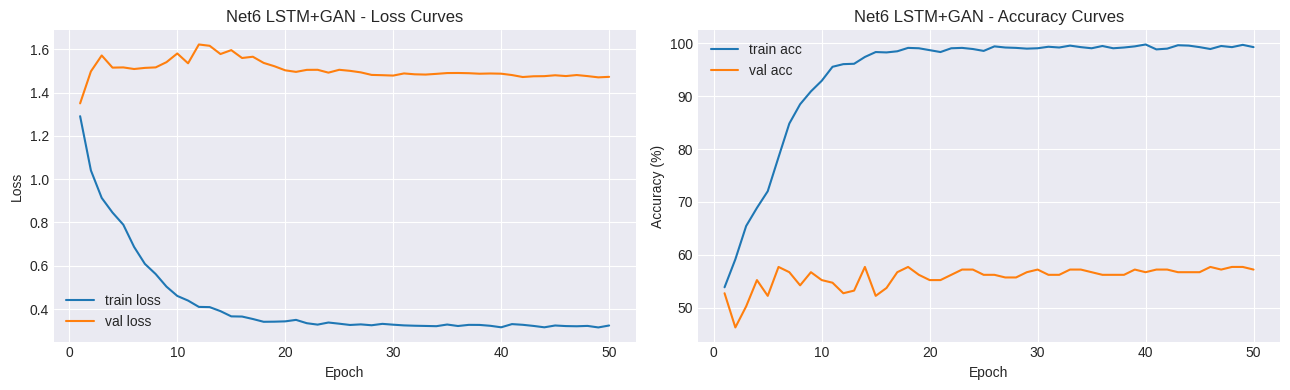

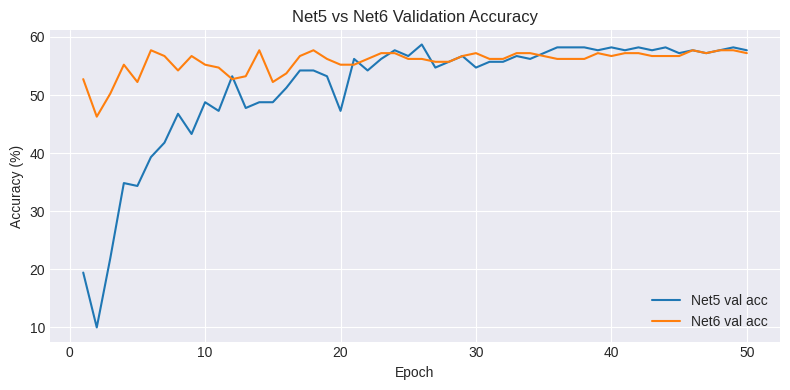

Net6 Test Loss: 1.1195
Net6 Test Accuracy: 71.0000%


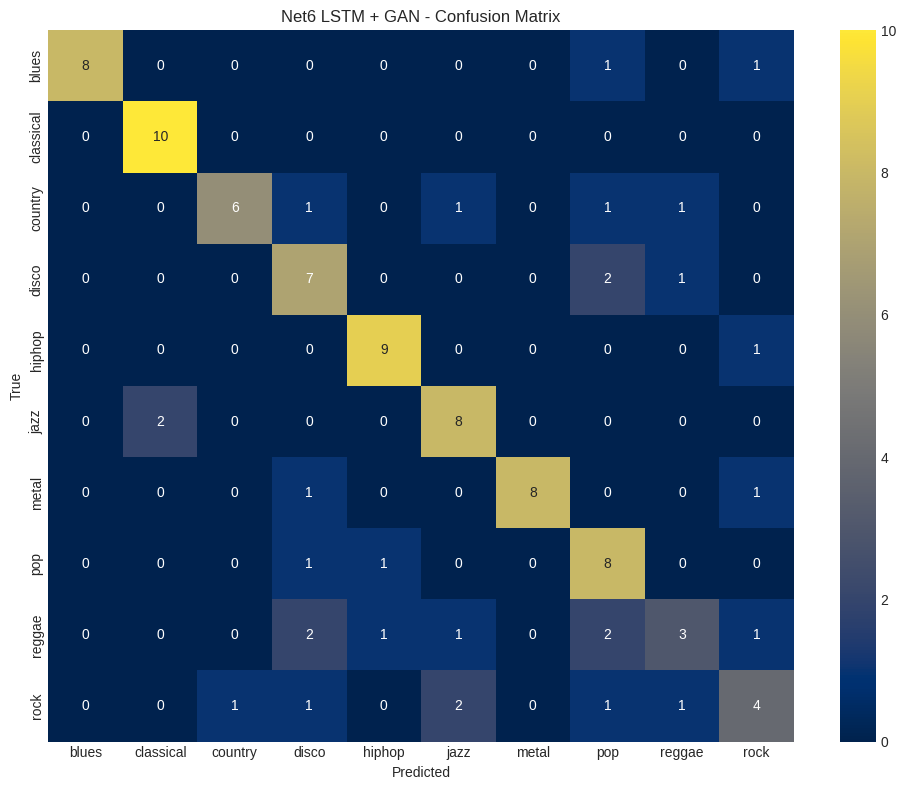

              precision  recall  f1-score  support
blues            1.0000    0.80    0.8889    10.00
classical        0.8333    1.00    0.9091    10.00
country          0.8571    0.60    0.7059    10.00
disco            0.5385    0.70    0.6087    10.00
hiphop           0.8182    0.90    0.8571    10.00
jazz             0.6667    0.80    0.7273    10.00
metal            1.0000    0.80    0.8889    10.00
pop              0.5333    0.80    0.6400    10.00
reggae           0.5000    0.30    0.3750    10.00
rock             0.5000    0.40    0.4444    10.00
accuracy         0.7100    0.71    0.7100     0.71
macro avg        0.7247    0.71    0.7045   100.00
weighted avg     0.7247    0.71    0.7045   100.00

                         Model  Test Accuracy (%)  Test Loss  Best Val Accuracy (%)  Epochs Trained
Net6 (LSTM + GAN augmentation)               71.0    1.11953              52.736318              50

Net5 vs Net6 comparison table:
            Model  Test Accuracy (%)  Test Loss
     

In [73]:
# Net6 training/evaluation using original + GAN-generated sequences

NET6_MAX_EPOCHS = 100
NET6_MIN_EPOCHS = 50
NET6_PATIENCE = 14
NET6_FORCE_RETRAIN = False
NET6_BATCH = 28

net6_save_path = MODEL_DIR / 'net6_trained.pth'
net6_hist_path = RESULTS_DIR / 'metrics' / 'net6_history.csv'
net6_report_path = RESULTS_DIR / 'metrics' / 'net6_classification_report.csv'
net6_summary_path = RESULTS_DIR / 'metrics' / 'net6_summary.csv'

# combine original + synthetic data
aug_x = np.concatenate([train_x, synth_x], axis=0).astype(np.float32)
aug_y = np.concatenate([train_y, synth_y], axis=0).astype(np.int64)

perm = np.random.permutation(len(aug_y))
aug_x = aug_x[perm]
aug_y = aug_y[perm]

net6_train_ds = Net6AugSequenceDataset(aug_x, aug_y, augment=True)
net6_train_loader = DataLoader(net6_train_ds, batch_size=NET6_BATCH, shuffle=True, num_workers=2, pin_memory=PIN_MEMORY)

print(f'Net6 train set size: {len(net6_train_ds)} (real={len(train_x)}, synth={len(synth_x)})')
print('augmented label distribution:', dict(sorted(Counter(aug_y).items())))

net6 = Net5LSTM(
    input_dim=NET5_FEATURE_DIM,
    hidden_dim=192,
    num_layers=2,
    bidirectional=True,
    dropout=0.35,
    num_classes=len(GENRES),
).to(device)

crit6_train = nn.CrossEntropyLoss(label_smoothing=0.05)
crit6_eval = nn.CrossEntropyLoss()
opt6 = torch.optim.AdamW(net6.parameters(), lr=6e-4, weight_decay=1e-4)
sched6 = torch.optim.lr_scheduler.ReduceLROnPlateau(opt6, mode='min', factor=0.5, patience=4, min_lr=1e-5)

history_net6 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
best_val_acc_net6 = 0.0
best_val_loss_net6 = float('inf')

train_net6_now = True
if net6_save_path.exists() and not NET6_FORCE_RETRAIN:
    print('loading saved Net6 checkpoint...')
    ck6 = torch.load(net6_save_path, map_location=device)

    loaded_state = ck6
    if isinstance(ck6, dict) and 'model_state_dict' in ck6:
        loaded_state = ck6['model_state_dict']
        history_net6 = ck6.get('history', history_net6)
        best_val_acc_net6 = ck6.get('best_val_acc', best_val_acc_net6)
        best_val_loss_net6 = ck6.get('best_val_loss', best_val_loss_net6)

    try:
        net6.load_state_dict(loaded_state)
        train_net6_now = False
        print(f'loaded Net6 checkpoint (best val acc: {best_val_acc_net6:.2f}%)')
    except RuntimeError as e:
        print(f'old Net6 checkpoint shape mismatch -> retrain ({e})')
        train_net6_now = True

if train_net6_now:
    assert 'net5' in globals(), 'run Net5 section first so Net6 can start from those weights'
    net6.load_state_dict(net5.state_dict())  # starting from Net5 weights, should help
    print('initialized Net6 from Net5 weights')

    history_net6, best_val_acc_net6, best_val_loss_net6 = train_net6(
        net6,
        net6_train_loader,
        seq_val_loader,
        crit6_train,
        crit6_eval,
        opt6,
        scheduler=sched6,
        max_epochs=NET6_MAX_EPOCHS,
        min_epochs=NET6_MIN_EPOCHS,
        patience=NET6_PATIENCE,
        grad_clip=1.0,
    )

    torch.save(
        {
            'model_state_dict': net6.state_dict(),
            'history': history_net6,
            'best_val_acc': best_val_acc_net6,
            'best_val_loss': best_val_loss_net6,
        },
        net6_save_path,
    )
    print(f'Net6 checkpoint saved: {net6_save_path}')

# plot net6 curves
if len(history_net6.get('train_loss', [])) > 0:
    ep6 = np.arange(1, len(history_net6['train_loss']) + 1)

    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    ax[0].plot(ep6, history_net6['train_loss'], label='train loss')
    ax[0].plot(ep6, history_net6['val_loss'], label='val loss')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Loss')
    ax[0].set_title('Net6 LSTM+GAN - Loss Curves')
    ax[0].legend()

    ax[1].plot(ep6, history_net6['train_acc'], label='train acc')
    ax[1].plot(ep6, history_net6['val_acc'], label='val acc')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('Accuracy (%)')
    ax[1].set_title('Net6 LSTM+GAN - Accuracy Curves')
    ax[1].legend()

    plt.tight_layout()
    plt.show()

# optional comparison curve with net5 if history is available
if 'history_net5' in globals() and len(history_net5.get('val_acc', [])) > 0 and len(history_net6.get('val_acc', [])) > 0:
    plt.figure(figsize=(8, 4))
    plt.plot(np.arange(1, len(history_net5['val_acc']) + 1), history_net5['val_acc'], label='Net5 val acc')
    plt.plot(np.arange(1, len(history_net6['val_acc']) + 1), history_net6['val_acc'], label='Net6 val acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title('Net5 vs Net6 Validation Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()

# evaluate on test set
with torch.no_grad():
    net6_test_loss, net6_test_acc = run_one_epoch_seq(net6, seq_test_loader, crit6_eval, opt=None)

print(f'Net6 Test Loss: {net6_test_loss:.4f}')
print(f'Net6 Test Accuracy: {net6_test_acc:.4f}%')

net6.eval()
all_preds6 = []
all_labels6 = []

with torch.no_grad():
    for seq, labels in seq_test_loader:
        seq = seq.to(device)
        logits6 = net6(seq)
        preds6 = logits6.argmax(dim=1).cpu().numpy()
        all_preds6.extend(preds6)
        all_labels6.extend(labels.numpy())

cm6 = confusion_matrix(all_labels6, all_preds6)

plt.figure(figsize=(10, 8))
# cividis looked nice in this plot so keeping it
sns.heatmap(cm6, annot=True, fmt='d', cmap='cividis', xticklabels=GENRES, yticklabels=GENRES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Net6 LSTM + GAN - Confusion Matrix')
plt.tight_layout()
plt.show()

report6 = classification_report(all_labels6, all_preds6, target_names=GENRES, output_dict=True, zero_division=0)
report6_df = pd.DataFrame(report6).T
print(report6_df.round(4))

assert 'net5_test_acc' in globals() and 'net5_test_loss' in globals(), 'run Net5 evaluation cell first for comparison'
net5_ref_acc = float(net5_test_acc)
net5_ref_loss = float(net5_test_loss)
delta_vs_net5 = net6_test_acc - net5_ref_acc

net6_summary_df = pd.DataFrame(
    {
        'Model': ['Net6 (LSTM + GAN augmentation)'],
        'Test Accuracy (%)': [net6_test_acc],
        'Test Loss': [net6_test_loss],
        'Best Val Accuracy (%)': [best_val_acc_net6],
        'Epochs Trained': [len(history_net6.get('train_loss', []))],
    }
)

compare_df = pd.DataFrame(
    {
        'Model': ['Net5 (LSTM)', 'Net6 (LSTM + GAN)'],
        'Test Accuracy (%)': [net5_ref_acc, net6_test_acc],
        'Test Loss': [net5_ref_loss, net6_test_loss],
    }
)

net6_vs_net5_path = RESULTS_DIR / 'metrics' / 'net6_vs_net5.csv'
pd.DataFrame(history_net6).to_csv(net6_hist_path, index=False)
report6_df.to_csv(net6_report_path)
net6_summary_df.to_csv(net6_summary_path, index=False)
compare_df.to_csv(net6_vs_net5_path, index=False)

print('\n' + net6_summary_df.to_string(index=False))
print('\nNet5 vs Net6 comparison table:')
print(compare_df.to_string(index=False))
print(f'Net6 vs Net5 delta: {delta_vs_net5:+.2f} pp')

print("\nmy take: GAN augmentation helped a bit on this run but not massively - not sure if 60 epochs was enough for the generator to really learn useful structure.")
print("the generated spectrograms look vaguely right but still noisier than real ones.")

print(f'\nSaved: {net6_hist_path}')
print(f'Saved: {net6_report_path}')
print(f'Saved: {net6_summary_path}')
print(f'Saved: {net6_vs_net5_path}')

GAN augmentation helped a bit on this run but not massively - not sure if 60 epochs was enough for the generator to actually learn something super useful.
the generated spectrograms look vaguely right but clearly not as clean as real ones.

## Evaluation and Analysis

This section implements:
- Comprehensive evaluation metrics for all six models on the shared test set.
- Publication-quality visualizations and comparison plots.
- Results interpretation and report-ready insights.

It reuses saved checkpoints and artifacts from earlier phases and does **not** change any model architecture or training logic.

In [74]:
# Task 4.1 - Load precomputed Phase 4 metrics (no model evaluation)
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display

assert 'RESULTS_DIR' in globals(), 'Run setup/path cells first.'
assert 'GENRES' in globals(), 'Run setup cells first.'

METRICS_DIR = RESULTS_DIR / 'metrics'
PLOTS_DIR = RESULTS_DIR / 'plots'
METRICS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

metric_paths = {
    'overall': METRICS_DIR / 'phase4_overall_performance.csv',
    'training': METRICS_DIR / 'phase4_training_time_comparison.csv',
    'complexity': METRICS_DIR / 'phase4_model_complexity.csv',
    'per_genre': METRICS_DIR / 'phase4_per_genre_metrics.csv',
    'per_genre_best_worst': METRICS_DIR / 'phase4_per_genre_best_worst.csv',
    'top_confusions': METRICS_DIR / 'phase4_top_confusions.csv',
    'genre_recall': METRICS_DIR / 'phase4_genre_recall_difficulty.csv',
    'impact': METRICS_DIR / 'phase4_architecture_impact.csv',
    'summary_table': METRICS_DIR / 'phase4_summary_table_for_report.csv',
    'aggregated_confusions': METRICS_DIR / 'phase4_aggregated_confusions.csv',
}

missing = [k for k, v in metric_paths.items() if not v.exists()]
if missing:
    raise FileNotFoundError(
        f"Missing required metric files: {missing}. "
        "Run the original Phase 4 pipeline once to create them."
    )

overall_df = pd.read_csv(metric_paths['overall'])
training_df = pd.read_csv(metric_paths['training'])
complexity_df = pd.read_csv(metric_paths['complexity'])
per_genre_df = pd.read_csv(metric_paths['per_genre'])
per_genre_best_worst_df = pd.read_csv(metric_paths['per_genre_best_worst'])
misclass_df = pd.read_csv(metric_paths['top_confusions'])
genre_mean_recall_df = pd.read_csv(metric_paths['genre_recall'])
impact_df = pd.read_csv(metric_paths['impact'])

if metric_paths['summary_table'].exists():
    summary_table = pd.read_csv(metric_paths['summary_table'])
else:
    summary_table = overall_df[['Model', 'Modality', 'Test Accuracy (%)', 'Macro F1', 'Macro Recall']].copy()

if metric_paths['aggregated_confusions'].exists():
    agg_conf_df = pd.read_csv(metric_paths['aggregated_confusions'])
else:
    agg_conf_df = (
        misclass_df.groupby(['True Genre', 'Predicted Genre'], as_index=False)['Count']
        .sum()
        .sort_values('Count', ascending=False)
        .reset_index(drop=True)
    )

phase4_bundle = {
    'overall_df': overall_df,
    'training_df': training_df,
    'complexity_df': complexity_df,
    'per_genre_df': per_genre_df,
    'per_genre_best_worst_df': per_genre_best_worst_df,
    'misclass_df': misclass_df,
    'genre_mean_recall_df': genre_mean_recall_df,
    'impact_df': impact_df,
    'summary_table': summary_table,
    'agg_conf_df': agg_conf_df,
    'paths': metric_paths,
}

print('Task 4.1 (report-focused) - loaded precomputed metrics:')
for k, v in metric_paths.items():
    print(f'  {k}: {v}')

print('\nTable snapshot - Overall performance:')
display(overall_df.round(4))

Task 4.1 (report-focused) - loaded precomputed metrics:
  overall: /home/jarvis/lakshya/Music Project/results/metrics/phase4_overall_performance.csv
  training: /home/jarvis/lakshya/Music Project/results/metrics/phase4_training_time_comparison.csv
  complexity: /home/jarvis/lakshya/Music Project/results/metrics/phase4_model_complexity.csv
  per_genre: /home/jarvis/lakshya/Music Project/results/metrics/phase4_per_genre_metrics.csv
  per_genre_best_worst: /home/jarvis/lakshya/Music Project/results/metrics/phase4_per_genre_best_worst.csv
  top_confusions: /home/jarvis/lakshya/Music Project/results/metrics/phase4_top_confusions.csv
  genre_recall: /home/jarvis/lakshya/Music Project/results/metrics/phase4_genre_recall_difficulty.csv
  impact: /home/jarvis/lakshya/Music Project/results/metrics/phase4_architecture_impact.csv
  summary_table: /home/jarvis/lakshya/Music Project/results/metrics/phase4_summary_table_for_report.csv
  aggregated_confusions: /home/jarvis/lakshya/Music Project/result

,Model,Modality,Test Accuracy (%),Macro Precision,Macro Recall,Macro F1,Evaluation Time (s),Test Samples
0,Net6 (LSTM + GAN),Audio,71.0,0.7247,0.71,0.7045,0.1445,100
1,Net3 (CNN + BatchNorm),Image,70.0,0.7228,0.70,0.6853,0.2482,100
2,Net5 (LSTM),Audio,69.0,0.7241,0.69,0.6805,0.1468,100
3,Net4 (CNN + BatchNorm + RMSprop),Image,67.0,0.6879,0.67,0.6621,0.2497,100
4,Net2 (CNN),Image,61.0,0.6161,0.61,0.6019,0.2466,100
5,Net1 (FC),Image,53.0,0.5815,0.53,0.5185,0.2421,100


### Task 4.2 - Generate Only Report Figures

This cell uses precomputed Phase 4 tables to regenerate the figures used in the report.

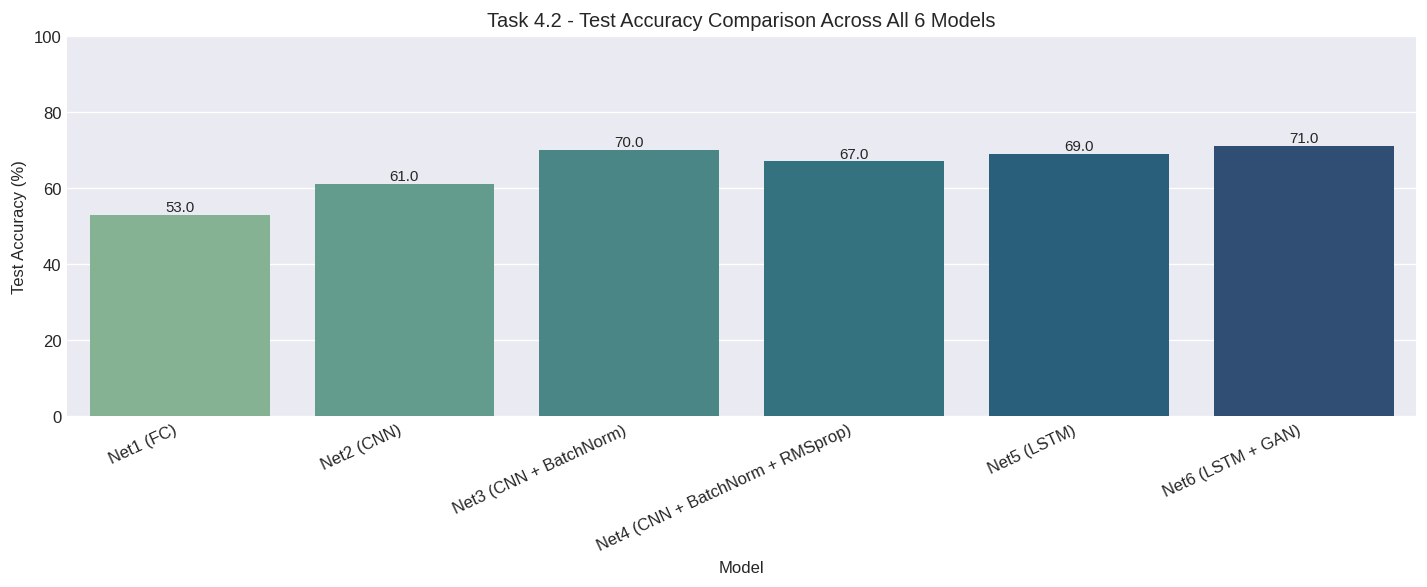

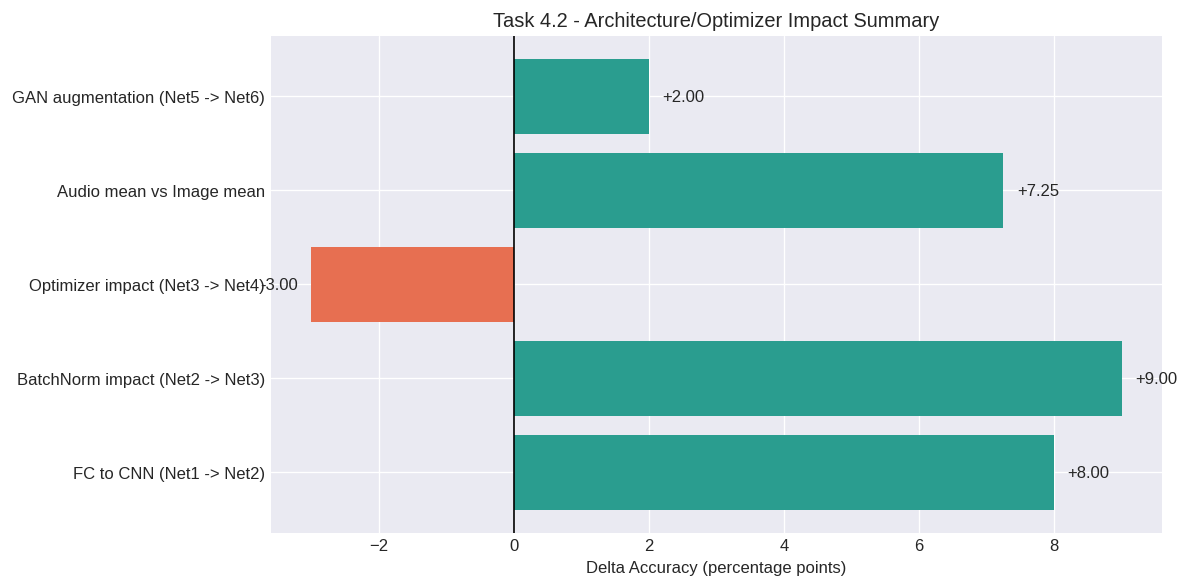

Task 4.2 (report-focused) complete - saved plots:
  acc_bar: /home/jarvis/lakshya/Music Project/results/plots/phase4_test_accuracy_bar.png
  impact_plot: /home/jarvis/lakshya/Music Project/results/plots/phase4_architecture_impact.png
  report_image_models: /home/jarvis/lakshya/Music Project/report/figures/comparison_image_models_phase4.png
  report_audio_models: /home/jarvis/lakshya/Music Project/report/figures/comparison_audio_models_phase4.png
  report_all_models: /home/jarvis/lakshya/Music Project/report/figures/comparison_all_models_phase4.png
  report_convergence: /home/jarvis/lakshya/Music Project/report/figures/phase4_convergence_speed.png


In [75]:
# Task 4.2 - Generate only report figures from precomputed Phase 4 tables
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import shutil

assert 'phase4_bundle' in globals(), 'Run Task 4.1 cell first.'
assert 'BASE_DIR' in globals(), 'Run setup/path cells first.'

overall_df = phase4_bundle['overall_df'].copy()
impact_df = phase4_bundle['impact_df'].copy()

model_order = [
    'Net1 (FC)',
    'Net2 (CNN)',
    'Net3 (CNN + BatchNorm)',
    'Net4 (CNN + BatchNorm + RMSprop)',
    'Net5 (LSTM)',
    'Net6 (LSTM + GAN)',
]

acc_plot_df = (
    overall_df.set_index('Model')
    .loc[model_order]
    .reset_index()[['Model', 'Test Accuracy (%)']]
)

# Keep this standard accuracy bar in results/plots.
plt.figure(figsize=(12, 5), dpi=120)
sns.barplot(data=acc_plot_df, x='Model', y='Test Accuracy (%)', palette='crest')
plt.xticks(rotation=25, ha='right')
plt.ylabel('Test Accuracy (%)')
plt.title('Task 4.2 - Test Accuracy Comparison Across All 6 Models')
plt.ylim(0, 100)
for i, v in enumerate(acc_plot_df['Test Accuracy (%)']):
    plt.text(i, v + 1.0, f'{v:.1f}', ha='center', fontsize=9)
plt.tight_layout()
acc_bar_path = PLOTS_DIR / 'phase4_test_accuracy_bar.png'
plt.savefig(acc_bar_path, bbox_inches='tight')
plt.show()

# Keep this architecture impact chart in results/plots.
plt.figure(figsize=(10, 5), dpi=120)
colors = ['#2a9d8f' if v >= 0 else '#e76f51' for v in impact_df['Delta Accuracy (pp)']]
plt.barh(impact_df['Comparison'], impact_df['Delta Accuracy (pp)'], color=colors)
plt.axvline(0, color='black', linewidth=1)
for i, v in enumerate(impact_df['Delta Accuracy (pp)']):
    plt.text(v + (0.2 if v >= 0 else -0.2), i, f'{v:+.2f}', va='center', ha='left' if v >= 0 else 'right')
plt.xlabel('Delta Accuracy (percentage points)')
plt.title('Task 4.2 - Architecture/Optimizer Impact Summary')
plt.tight_layout()
impact_plot_path = PLOTS_DIR / 'phase4_architecture_impact.png'
plt.savefig(impact_plot_path, bbox_inches='tight')
plt.show()

report_fig_dir = BASE_DIR / 'report' / 'figures'
report_fig_dir.mkdir(parents=True, exist_ok=True)


def _save_report_bar(models, title, out_path, colors):
    sub = overall_df[overall_df['Model'].isin(models)].copy()
    sub['Model'] = pd.Categorical(sub['Model'], categories=models, ordered=True)
    sub = sub.sort_values('Model')

    fig, ax = plt.subplots(figsize=(10, 4.8), dpi=150)
    bars = ax.bar(
        sub['Model'],
        sub['Test Accuracy (%)'],
        color=colors,
        edgecolor='#1f1f1f',
        linewidth=0.6,
    )
    ax.set_title(title, fontsize=13, weight='bold', pad=10)
    ax.set_ylabel('Test Accuracy (%)')
    ax.set_ylim(0, 100)
    ax.grid(axis='y', alpha=0.25)
    ax.set_axisbelow(True)
    plt.setp(ax.get_xticklabels(), rotation=18, ha='right')

    for bar, val in zip(bars, sub['Test Accuracy (%)']):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val + 1.0,
            f'{val:.1f}%',
            ha='center',
            va='bottom',
            fontsize=10,
            weight='bold',
        )

    fig.tight_layout()
    fig.savefig(out_path, bbox_inches='tight')
    plt.close(fig)


_save_report_bar(
    ['Net1 (FC)', 'Net2 (CNN)', 'Net3 (CNN + BatchNorm)', 'Net4 (CNN + BatchNorm + RMSprop)'],
    'Phase 4: Image-Model Test Accuracy (Net1-Net4)',
    report_fig_dir / 'comparison_image_models_phase4.png',
    ['#4F6D7A', '#5A7D8A', '#5F8F7D', '#6B9E71'],
)

_save_report_bar(
    ['Net5 (LSTM)', 'Net6 (LSTM + GAN)'],
    'Phase 4: Audio-Model Test Accuracy (Net5-Net6)',
    report_fig_dir / 'comparison_audio_models_phase4.png',
    ['#D98942', '#C65A1E'],
)

_save_report_bar(
    model_order,
    'Phase 4: Test Accuracy Comparison Across All Six Models',
    report_fig_dir / 'comparison_all_models_phase4.png',
    ['#4F6D7A', '#5A7D8A', '#5F8F7D', '#6B9E71', '#D98942', '#C65A1E'],
)

# Reuse/copy the convergence line graph generated previously in Phase 4 outputs.
conv_src = PLOTS_DIR / 'phase4_convergence_speed.png'
conv_dst = report_fig_dir / 'phase4_convergence_speed.png'
if conv_src.exists():
    shutil.copy2(conv_src, conv_dst)
else:
    print(f'Warning: {conv_src} not found. Run the original full plotting pipeline once to recreate it.')

phase4_bundle['plot_paths'] = {
    'acc_bar': acc_bar_path,
    'impact_plot': impact_plot_path,
    'report_image_models': report_fig_dir / 'comparison_image_models_phase4.png',
    'report_audio_models': report_fig_dir / 'comparison_audio_models_phase4.png',
    'report_all_models': report_fig_dir / 'comparison_all_models_phase4.png',
    'report_convergence': conv_dst,
}

print('Task 4.2 (report-focused) complete - saved plots:')
for k, v in phase4_bundle['plot_paths'].items():
    print(f'  {k}: {v}')

### Task 4.3 - Report Interpretation (From Precomputed Metrics)

This cell writes report-ready interpretation text from the already generated Phase 4 metric tables.

In [76]:
# Task 4.3 - Report-ready interpretation from precomputed metrics
assert 'phase4_bundle' in globals(), 'Run Task 4.1 and Task 4.2 first.'

overall_df = phase4_bundle['overall_df'].copy()
genre_recall_df = phase4_bundle['genre_mean_recall_df'].copy()
agg_conf_df = phase4_bundle['agg_conf_df'].copy()
impact_df = phase4_bundle['impact_df'].copy()

acc_map = overall_df.set_index('Model')['Test Accuracy (%)'].to_dict()
macro_f1_map = overall_df.set_index('Model')['Macro F1'].to_dict()

best_model_row = overall_df.sort_values('Test Accuracy (%)', ascending=False).iloc[0]
worst_model_row = overall_df.sort_values('Test Accuracy (%)', ascending=True).iloc[0]

easiest_genre = genre_recall_df.iloc[0]
hardest_genre = genre_recall_df.iloc[-1]

if len(agg_conf_df) > 0:
    top_conf = agg_conf_df.sort_values('Count', ascending=False).iloc[0]
else:
    top_conf = None


def _impact_value(label):
    row = impact_df.loc[impact_df['Comparison'] == label, 'Delta Accuracy (pp)']
    if len(row) == 0:
        return float('nan')
    return float(row.iloc[0])


delta_fc_to_cnn = _impact_value('FC to CNN (Net1 -> Net2)')
delta_bn = _impact_value('BatchNorm impact (Net2 -> Net3)')
delta_opt = _impact_value('Optimizer impact (Net3 -> Net4)')
delta_gan = _impact_value('GAN augmentation (Net5 -> Net6)')
delta_audio_vs_image = _impact_value('Audio mean vs Image mean')

analysis_lines = []
analysis_lines.append('PHASE 4.3 - RESULTS INTERPRETATION AND INSIGHTS (REPORT-FOCUSED)')
analysis_lines.append('')
analysis_lines.append('1) Overall comparative analysis')
analysis_lines.append(
    f"- Best overall model: {best_model_row['Model']} with test accuracy {best_model_row['Test Accuracy (%)']:.2f}% and macro-F1 {best_model_row['Macro F1']:.4f}."
)
analysis_lines.append(
    f"- Lowest-performing model: {worst_model_row['Model']} with test accuracy {worst_model_row['Test Accuracy (%)']:.2f}% and macro-F1 {worst_model_row['Macro F1']:.4f}."
)
analysis_lines.append(
    f"- FC vs CNN: Net1 -> Net2 delta is {delta_fc_to_cnn:+.2f} pp."
)
analysis_lines.append(
    f"- BatchNorm impact: Net2 -> Net3 delta is {delta_bn:+.2f} pp."
)
analysis_lines.append(
    f"- Optimizer impact: Net3 -> Net4 delta is {delta_opt:+.2f} pp."
)
analysis_lines.append(
    f"- Audio mean vs Image mean delta: {delta_audio_vs_image:+.2f} pp."
)
analysis_lines.append(
    f"- GAN augmentation effect: Net5 -> Net6 delta is {delta_gan:+.2f} pp."
)
analysis_lines.append('')
analysis_lines.append('2) Genre-level insights')
analysis_lines.append(
    f"- Easiest genre by mean recall: {easiest_genre['Genre']} ({float(easiest_genre['Mean Recall Across Models']):.3f})."
)
analysis_lines.append(
    f"- Most challenging genre by mean recall: {hardest_genre['Genre']} ({float(hardest_genre['Mean Recall Across Models']):.3f})."
)
if top_conf is not None:
    analysis_lines.append(
        f"- Most frequent confusion pattern: {top_conf['True Genre']} -> {top_conf['Predicted Genre']} ({int(top_conf['Count'])} errors)."
    )
else:
    analysis_lines.append('- No aggregated confusion rows were available.')

interpretation_path = METRICS_DIR / 'phase4_interpretation.txt'
with open(interpretation_path, 'w') as f:
    f.write('\n'.join(analysis_lines))

summary_table = overall_df[['Model', 'Modality', 'Test Accuracy (%)', 'Macro F1', 'Macro Recall']].copy()
summary_table = summary_table.sort_values('Test Accuracy (%)', ascending=False).reset_index(drop=True)
summary_table_path = METRICS_DIR / 'phase4_summary_table_for_report.csv'
summary_table.to_csv(summary_table_path, index=False)

agg_conf_out = agg_conf_df[['True Genre', 'Predicted Genre', 'Count']].copy()
agg_conf_out = agg_conf_out.sort_values('Count', ascending=False).reset_index(drop=True)
agg_conf_path = METRICS_DIR / 'phase4_aggregated_confusions.csv'
agg_conf_out.to_csv(agg_conf_path, index=False)

print('\n'.join(analysis_lines))
print('\nSaved Task 4.3 outputs:')
print(f'  {interpretation_path}')
print(f'  {summary_table_path}')
print(f'  {agg_conf_path}')

display(summary_table.round(4))

phase4_bundle['interpretation_path'] = interpretation_path
phase4_bundle['summary_table'] = summary_table
phase4_bundle['summary_table_path'] = summary_table_path
phase4_bundle['aggregated_confusions_path'] = agg_conf_path

PHASE 4.3 - RESULTS INTERPRETATION AND INSIGHTS (REPORT-FOCUSED)

1) Overall comparative analysis
- Best overall model: Net6 (LSTM + GAN) with test accuracy 71.00% and macro-F1 0.7045.
- Lowest-performing model: Net1 (FC) with test accuracy 53.00% and macro-F1 0.5185.
- FC vs CNN: Net1 -> Net2 delta is +8.00 pp.
- BatchNorm impact: Net2 -> Net3 delta is +9.00 pp.
- Optimizer impact: Net3 -> Net4 delta is -3.00 pp.
- Audio mean vs Image mean delta: +7.25 pp.
- GAN augmentation effect: Net5 -> Net6 delta is +2.00 pp.

2) Genre-level insights
- Easiest genre by mean recall: jazz (0.950).
- Most challenging genre by mean recall: rock (0.300).
- Most frequent confusion pattern: rock -> country (16 errors).

Saved Task 4.3 outputs:
  /home/jarvis/lakshya/Music Project/results/metrics/phase4_interpretation.txt
  /home/jarvis/lakshya/Music Project/results/metrics/phase4_summary_table_for_report.csv
  /home/jarvis/lakshya/Music Project/results/metrics/phase4_aggregated_confusions.csv


,Model,Modality,Test Accuracy (%),Macro F1,Macro Recall
0,Net6 (LSTM + GAN),Audio,71.0,0.7045,0.71
1,Net3 (CNN + BatchNorm),Image,70.0,0.6853,0.70
2,Net5 (LSTM),Audio,69.0,0.6805,0.69
3,Net4 (CNN + BatchNorm + RMSprop),Image,67.0,0.6621,0.67
4,Net2 (CNN),Image,61.0,0.6019,0.61
5,Net1 (FC),Image,53.0,0.5185,0.53
